<a href="https://colab.research.google.com/github/obaidah3/world-bank-data-mining-pipeline/blob/main/WEB_Scraping_ETL_Professional_Enhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a237e 0%, #0d47a1 50%, #01579b 100%);
            padding: 40px 30px; border-radius: 12px; text-align: center; color: white;
            font-family: 'Segoe UI', sans-serif; margin-bottom: 20px;">
    <h1 style="margin:0; font-size:2.2em; letter-spacing:1px;">
         End-to-End Web Scraping & Data Mining Pipeline
    </h1>
    <h3 style="margin:10px 0 0 0; font-weight:300; opacity:0.9;">
        ETL · Frequent Pattern Mining · Clustering · Classification
    </h3>
    <p style="margin:15px 0 0 0; opacity:0.75; font-size:0.9em;">
        World Bank Open Data API · 7 Countries · 6 Macroeconomic Indicators · 20+ Years
    </p>
</div>

---
## Abstract
This notebook implements a production-grade Extract–Transform–Load (ETL) pipeline targeting the **World Bank Open Data API** — a publicly accessible, richly structured source that provides standardised macroeconomic indicators for every country worldwide. Because the API delivers raw JSON rather than pre-processed tables, it mirrors the challenges of real-world web-scraping: heterogeneous missing-value patterns, unit inconsistencies, and multi-dimensional data shapes that must be pivoted before analysis.

The pipeline proceeds through five stages:
1. **Extraction** — HTTP requests with retry logic, paginated responses, and **parallel** country fetching via `ThreadPoolExecutor`
2. **Transformation** — deduplication, per-country outlier winsorisation, gap-fill interpolation, and schema normalisation
3. **Loading** — persistence to both CSV (ad-hoc analytics) and SQLite (structured queries)
4. **Mining** — frequent pattern mining via Apriori/FP-Growth (HIGH-flag only, non-trivial rules), K-Means + UMAP clustering, and multi-model classification with cross-validation
5. **Reporting** — a self-contained dashboard cell that consolidates all key findings

**Keywords:** Web Scraping, ETL, Association Rule Mining, K-Means Clustering, Random Forest, World Bank API, Macroeconomic Analytics

---
## Section 1 · Environment Setup & Configuration

All dependencies are declared once here. A `PipelineConfig` dataclass acts as the single source of truth for every hyperparameter used downstream.

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 1 · Environment Setup & Configuration
# ──────────────────────────────────────────────────────────────────
import warnings, logging, time, sqlite3, random, os, itertools
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import joblib
import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

# ── Optional UMAP (graceful fallback) ──────────────────────────────
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("\u2139\ufe0f  umap-learn not found \u2014 UMAP plot will be skipped. Install: pip install umap-learn")

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s  %(levelname)-8s  %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("pipeline")

# ── Global aesthetics ───────────────────────────────────────────────
PALETTE = ["#1565C0", "#E53935", "#2E7D32", "#F57F17", "#6A1B9A",
           "#00838F", "#AD1457", "#4E342E"]
BLUE_CMAP = LinearSegmentedColormap.from_list("blues_custom",
                                               ["#E3F2FD", "#0D47A1"])
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titlepad": 10,
                     "axes.labelpad": 6, "figure.autolayout": True})

# ── Pipeline Configuration ──────────────────────────────────────────
# PipelineConfig is the single source of truth for all hyperparameters.
# Adjust fields here; every downstream cell reads from `cfg`.
@dataclass
class PipelineConfig:
    # Data Source
    base_url:        str   = "https://api.worldbank.org/v2"
    countries:       List  = field(default_factory=lambda: ["EGY","USA","FRA","DEU","CHN","BRA","IND"])
    indicators:      Dict  = field(default_factory=lambda: {
        "GDP_PC":      "NY.GDP.PCAP.CD",   # GDP per capita (USD)
        "UNEMP":       "SL.UEM.TOTL.ZS",   # Unemployment rate (%)
        "INFLATION":   "FP.CPI.TOTL.ZG",   # Inflation, CPI (%)
        "POPULATION":  "SP.POP.TOTL",       # Total population
        "LIFE_EXP":    "SP.DYN.LE00.IN",   # Life expectancy (years)
        "INTERNET":    "IT.NET.USER.ZS",    # Internet users (%)
    })
    per_page:        int   = 100
    start_year:      int   = 2000
    end_year:        int   = 2023
    # Storage
    data_dir:        str   = "pipeline_data"
    raw_csv:         str   = "raw_worldbank.csv"
    clean_csv:       str   = "clean_worldbank.csv"
    db_path:         str   = "worldbank.db"
    # Mining
    n_clusters:      int   = 4
    kmeans_n_init:   int   = 20          # Consistent across elbow + final fit
    min_support:     float = 0.25
    min_confidence:  float = 0.60
    min_lift:        float = 1.0
    test_size:       float = 0.20
    cv_folds:        int   = 5
    random_state:    int   = 42
    # Parallel fetch
    fetch_workers:   int   = 4           # ThreadPoolExecutor max_workers

cfg = PipelineConfig()
from pathlib import Path
Path(cfg.data_dir).mkdir(exist_ok=True)
log.info("\u2705  Configuration loaded \u2014 %d countries, %d indicators",
         len(cfg.countries), len(cfg.indicators))
print(f"\nData directory  : {cfg.data_dir}/")
print(f"Countries       : {', '.join(cfg.countries)}")
print(f"Indicators      : {', '.join(cfg.indicators.keys())}")
print(f"Year range      : {cfg.start_year}\u2013{cfg.end_year}")


Data directory  : pipeline_data/
Countries       : EGY, USA, FRA, DEU, CHN, BRA, IND
Indicators      : GDP_PC, UNEMP, INFLATION, POPULATION, LIFE_EXP, INTERNET
Year range      : 2000–2023


---
## Section 2 · Data Extraction  (ETL: **Extract**)

### 2.1 Web-Scraping Architecture

The World Bank REST API returns JSON pages. The extractor below implements:
- **Retry logic** with exponential back-off (handles transient 429 / 503 errors)
- **Pagination** cursor — `page` parameter walks through all result pages
- **Parallel fetching** — `ThreadPoolExecutor` fetches all country×indicator combinations concurrently (configurable via `cfg.fetch_workers`)
- **Rate limiting** — a randomised sleep of 0.2–0.6 s between requests keeps the pipeline polite
- **Data provenance** — every record carries `fetch_ts` (timestamp) and `source_url`

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 2 · Data Extraction
# ──────────────────────────────────────────────────────────────────

class WorldBankScraper:
    """HTTP client for the World Bank Indicators REST API (v2).

    Supports parallel country × indicator fetching via ThreadPoolExecutor,
    exponential back-off retries, and full pagination.
    """

    def __init__(self, config: PipelineConfig) -> None:
        self.cfg  = config
        self.sess = requests.Session()
        self.sess.headers.update({"User-Agent": "WB-ETL-Pipeline/1.0"})
        # Connection pooling: reuse TCP connections across parallel threads
        adapter = requests.adapters.HTTPAdapter(
            pool_connections=cfg.fetch_workers,
            pool_maxsize=cfg.fetch_workers * 2
        )
        self.sess.mount("https://", adapter)

    def _get(self, url: str, retries: int = 4) -> Optional[Dict]:
        """GET with exponential back-off. Returns parsed JSON or None."""
        for attempt in range(retries):
            try:
                r = self.sess.get(url, timeout=15)
                if r.status_code == 200:
                    return r.json()
                log.warning("HTTP %s \u2014 attempt %d/%d", r.status_code, attempt+1, retries)
            except requests.RequestException as exc:
                log.warning("Request failed (%s) \u2014 retry %d/%d", exc, attempt+1, retries)
            time.sleep((2 ** attempt) + random.uniform(0.2, 0.6))
        log.error("Giving up on %s", url)
        return None

    def fetch_indicator(self, country: str, indicator_name: str,
                        indicator_code: str) -> List[Dict]:
        """Fetch all paginated records for one country × indicator pair."""
        records, page = [], 1
        while True:
            url = (f"{self.cfg.base_url}/country/{country}"
                   f"/indicator/{indicator_code}"
                   f"?format=json&per_page={self.cfg.per_page}"
                   f"&date={self.cfg.start_year}:{self.cfg.end_year}"
                   f"&page={page}")
            data = self._get(url)
            if not data or len(data) < 2 or not data[1]:
                break
            meta = data[0]
            for item in data[1]:
                records.append({
                    "country_code":     country,
                    "country_name":     item.get("country", {}).get("value", ""),
                    "indicator_name":   indicator_name,
                    "indicator_code":   indicator_code,
                    "year":             int(item["date"]),
                    "value":            item["value"],
                    "source_url":       url,
                    "fetch_ts":         pd.Timestamp.now().isoformat(),
                })
            if page >= meta.get("pages", 1):
                break
            page += 1
            time.sleep(random.uniform(0.2, 0.5))
        return records

    def fetch_all(self) -> pd.DataFrame:
        """Fetch all country × indicator combinations in parallel."""
        tasks = [
            (country, name, code)
            for country in self.cfg.countries
            for name, code in self.cfg.indicators.items()
        ]
        all_records = []

        with ThreadPoolExecutor(max_workers=self.cfg.fetch_workers) as pool:
            futures = {
                pool.submit(self.fetch_indicator, country, name, code): (country, name)
                for country, name, code in tasks
            }
            for future in tqdm(as_completed(futures), total=len(futures),
                               desc="Fetching indicators", unit="req"):
                country, name = futures[future]
                try:
                    all_records.extend(future.result())
                except Exception as exc:
                    log.error("\u2717  %s \u2192 %s failed: %s", country, name, exc)

        df = pd.DataFrame(all_records)
        if df.empty:
            raise RuntimeError("No data fetched \u2014 check network or API availability.")
        df["year"]  = pd.to_numeric(df["year"],  errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        return df


scraper  = WorldBankScraper(cfg)
df_raw   = scraper.fetch_all()

# ── Persist raw snapshot ────────────────────────────────────────────
raw_path = f"{cfg.data_dir}/{cfg.raw_csv}"
df_raw.to_csv(raw_path, index=False)
log.info("Raw data saved \u2192 %s  (%d rows, %d cols)", raw_path, *df_raw.shape)

print(f"\n{'='*60}")
print(f"  RAW EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"  Total records        : {len(df_raw):,}")
print(f"  Countries            : {df_raw['country_code'].nunique()}")
print(f"  Indicators           : {df_raw['indicator_name'].nunique()}")
print(f"  Year range           : {df_raw['year'].min()}\u2013{df_raw['year'].max()}")
print(f"  Missing values       : {df_raw['value'].isna().sum():,} "
      f"({df_raw['value'].isna().mean()*100:.1f}%)")
print(f"{'='*60}")
df_raw.head(10)

Fetching indicators:   0%|          | 0/42 [00:00<?, ?req/s]


  RAW EXTRACTION SUMMARY
  Total records        : 1,008
  Countries            : 7
  Indicators           : 6
  Year range           : 2000–2023
  Missing values       : 0 (0.0%)


,country_code,country_name,indicator_name,indicator_code,year,value,source_url,fetch_ts
0,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2023,33.884776,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217493
1,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2022,13.895661,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217562
2,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2021,5.214049,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217573
3,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2020,5.044933,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217583
4,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2019,9.152800,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217590
5,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2018,14.401466,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217596
6,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2017,29.506608,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217603
7,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2016,13.813606,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217609
8,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2015,10.370490,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217614
9,EGY,"Egypt, Arab Rep.",INFLATION,FP.CPI.TOTL.ZG,2014,10.070215,https://api.worldbank.org/v2/country/EGY/indic...,2026-05-21T07:59:40.217620


### 2.2 Raw Data Snapshot

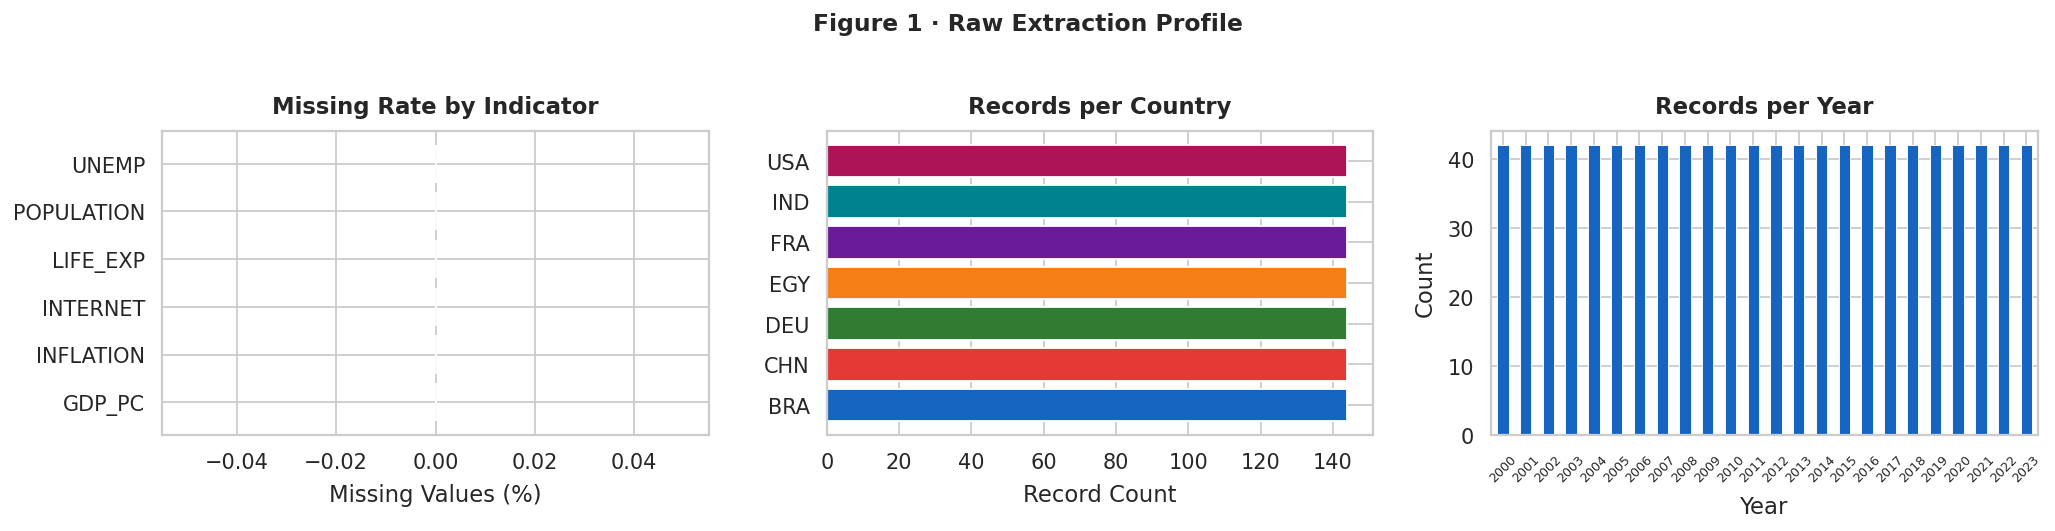

In [ ]:
# ── Raw data profile ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Missing values per indicator
mv = (df_raw.groupby("indicator_name")["value"]
      .apply(lambda s: s.isna().mean() * 100)
      .sort_values(ascending=True))
axes[0].barh(mv.index, mv.values, color=PALETTE[:len(mv)])
axes[0].set_xlabel("Missing Values (%)")
axes[0].set_title("Missing Rate by Indicator", fontweight="bold")

# Records per country
rc = df_raw.groupby("country_code").size().sort_values(ascending=True)
axes[1].barh(rc.index, rc.values, color=PALETTE[:len(rc)])
axes[1].set_xlabel("Record Count")
axes[1].set_title("Records per Country", fontweight="bold")

# Records per year
df_raw["year"].value_counts().sort_index().plot(ax=axes[2], kind="bar",
    color=PALETTE[0], edgecolor="white", linewidth=0.5)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Count")
axes[2].set_title("Records per Year", fontweight="bold")
axes[2].tick_params(axis="x", labelrotation=45, labelsize=7)

plt.suptitle("Figure 1 · Raw Extraction Profile", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig1_raw_profile.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 3 · Data Cleaning  (ETL: **Transform** — Stage I)

### Cleaning Protocol

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Drop structural duplicates | API pagination can return overlapping pages |
| 2 | Filter year range | Restrict to configured `start_year`–`end_year` |
| 3 | Pivot long → wide | One row per (country, year); one column per indicator |
| 4 | Interpolate gaps | Vectorised per-country linear interpolation preserves trend signal |
| 5 | Forward / back fill | Handle leading/trailing NaN after interpolation |
| 6 | **Per-country** winsorise outliers | Cap at 1st/99th percentile **within each country** to preserve cross-country structural differences |
| 7 | Drop residual NaN rows | Any row still incomplete after imputation is removed |

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 3 · Data Cleaning
# ──────────────────────────────────────────────────────────────────

def clean_pipeline(df: pd.DataFrame, cfg: PipelineConfig) -> pd.DataFrame:
    step_log = []

    # Step 1 — duplicates
    before = len(df)
    df = df.drop_duplicates(subset=["country_code","indicator_name","year"])
    step_log.append(("Duplicate rows removed", before - len(df)))

    # Step 2 — year filter
    before = len(df)
    df = df[df["year"].between(cfg.start_year, cfg.end_year)]
    step_log.append(("Rows outside year range", before - len(df)))

    # Step 3 — pivot long → wide
    df_wide = (df.pivot_table(index=["country_code","country_name","year"],
                               columns="indicator_name", values="value")
                 .reset_index())
    df_wide.columns.name = None
    expected_cols = list(cfg.indicators.keys())
    present_cols  = [c for c in expected_cols if c in df_wide.columns]
    df_wide = df_wide[["country_code","country_name","year"] + present_cols]

    num_cols = present_cols

    # Step 4 — vectorised per-country time-series interpolation
    df_wide = df_wide.sort_values(["country_code","year"])
    df_wide[num_cols] = (
        df_wide.groupby("country_code")[num_cols]
               .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )

    # Step 5 — forward / back fill residuals
    df_wide[num_cols] = (df_wide.groupby("country_code")[num_cols]
                                .transform(lambda s: s.ffill().bfill()))

    # Step 6 — PER-COUNTRY winsorisation (preserves cross-country structural differences)
    # Global winsorisation would incorrectly clip valid country-specific extremes
    # (e.g. CHN/IND population is structurally larger than FRA/DEU — not an outlier).
    def winsorise(s: pd.Series) -> pd.Series:
        lo, hi = s.quantile([0.01, 0.99])
        return s.clip(lo, hi)

    for col in num_cols:
        df_wide[col] = df_wide.groupby("country_code")[col].transform(winsorise)

    # Step 7 — drop residual NaN rows
    before = len(df_wide)
    df_wide = df_wide.dropna(subset=num_cols)
    step_log.append(("Rows with residual NaN", before - len(df_wide)))

    df_wide = df_wide.reset_index(drop=True)

    # Log
    print(f"\n{'\u2500'*55}")
    print(f"  DATA CLEANING REPORT")
    print(f"{'\u2500'*55}")
    for label, count in step_log:
        print(f"  {label:<35}  {count:>5,}")
    print(f"{'\u2500'*55}")
    print(f"  Final shape                          "
          f"  {df_wide.shape[0]:>5,} rows \u00d7 {df_wide.shape[1]} cols")
    print(f"{'\u2500'*55}")
    return df_wide


df_clean = clean_pipeline(df_raw, cfg)

# ── Persist cleaned data ────────────────────────────────────────────
clean_path = f"{cfg.data_dir}/{cfg.clean_csv}"
df_clean.to_csv(clean_path, index=False)

# ── SQLite persistence ──────────────────────────────────────────────
db_path = f"{cfg.data_dir}/{cfg.db_path}"
with sqlite3.connect(db_path) as conn:
    df_raw.to_sql("raw_data",   conn, if_exists="replace", index=False)
    df_clean.to_sql("clean_data", conn, if_exists="replace", index=False)
log.info("SQLite database written \u2192 %s", db_path)

df_clean.head(8)


───────────────────────────────────────────────────────
  DATA CLEANING REPORT
───────────────────────────────────────────────────────
  Duplicate rows removed                   0
  Rows outside year range                  0
  Rows with residual NaN                   0
───────────────────────────────────────────────────────
  Final shape                              168 rows × 9 cols
───────────────────────────────────────────────────────


,country_code,country_name,year,GDP_PC,UNEMP,INFLATION,POPULATION,LIFE_EXP,INTERNET
0,BRA,Brazil,2000,3766.547863,10.889,7.044141,1.745434e+08,69.67508,3.251981
1,BRA,Brazil,2001,3176.289751,10.649,6.840359,1.763012e+08,69.98000,4.528495
2,BRA,Brazil,2002,2909.913517,10.641,8.450164,1.785035e+08,70.39600,9.149425
3,BRA,Brazil,2003,3090.606891,11.168,13.464913,1.806227e+08,70.88400,13.207586
4,BRA,Brazil,2004,3663.822625,10.072,6.597185,1.826751e+08,71.36100,19.073672
5,BRA,Brazil,2005,4827.781659,10.551,6.869537,1.846881e+08,71.83200,21.022747
6,BRA,Brazil,2006,5934.145619,9.692,4.183568,1.866531e+08,72.29600,28.178400
7,BRA,Brazil,2007,7409.690038,9.280,3.641273,1.885523e+08,72.73000,30.879999


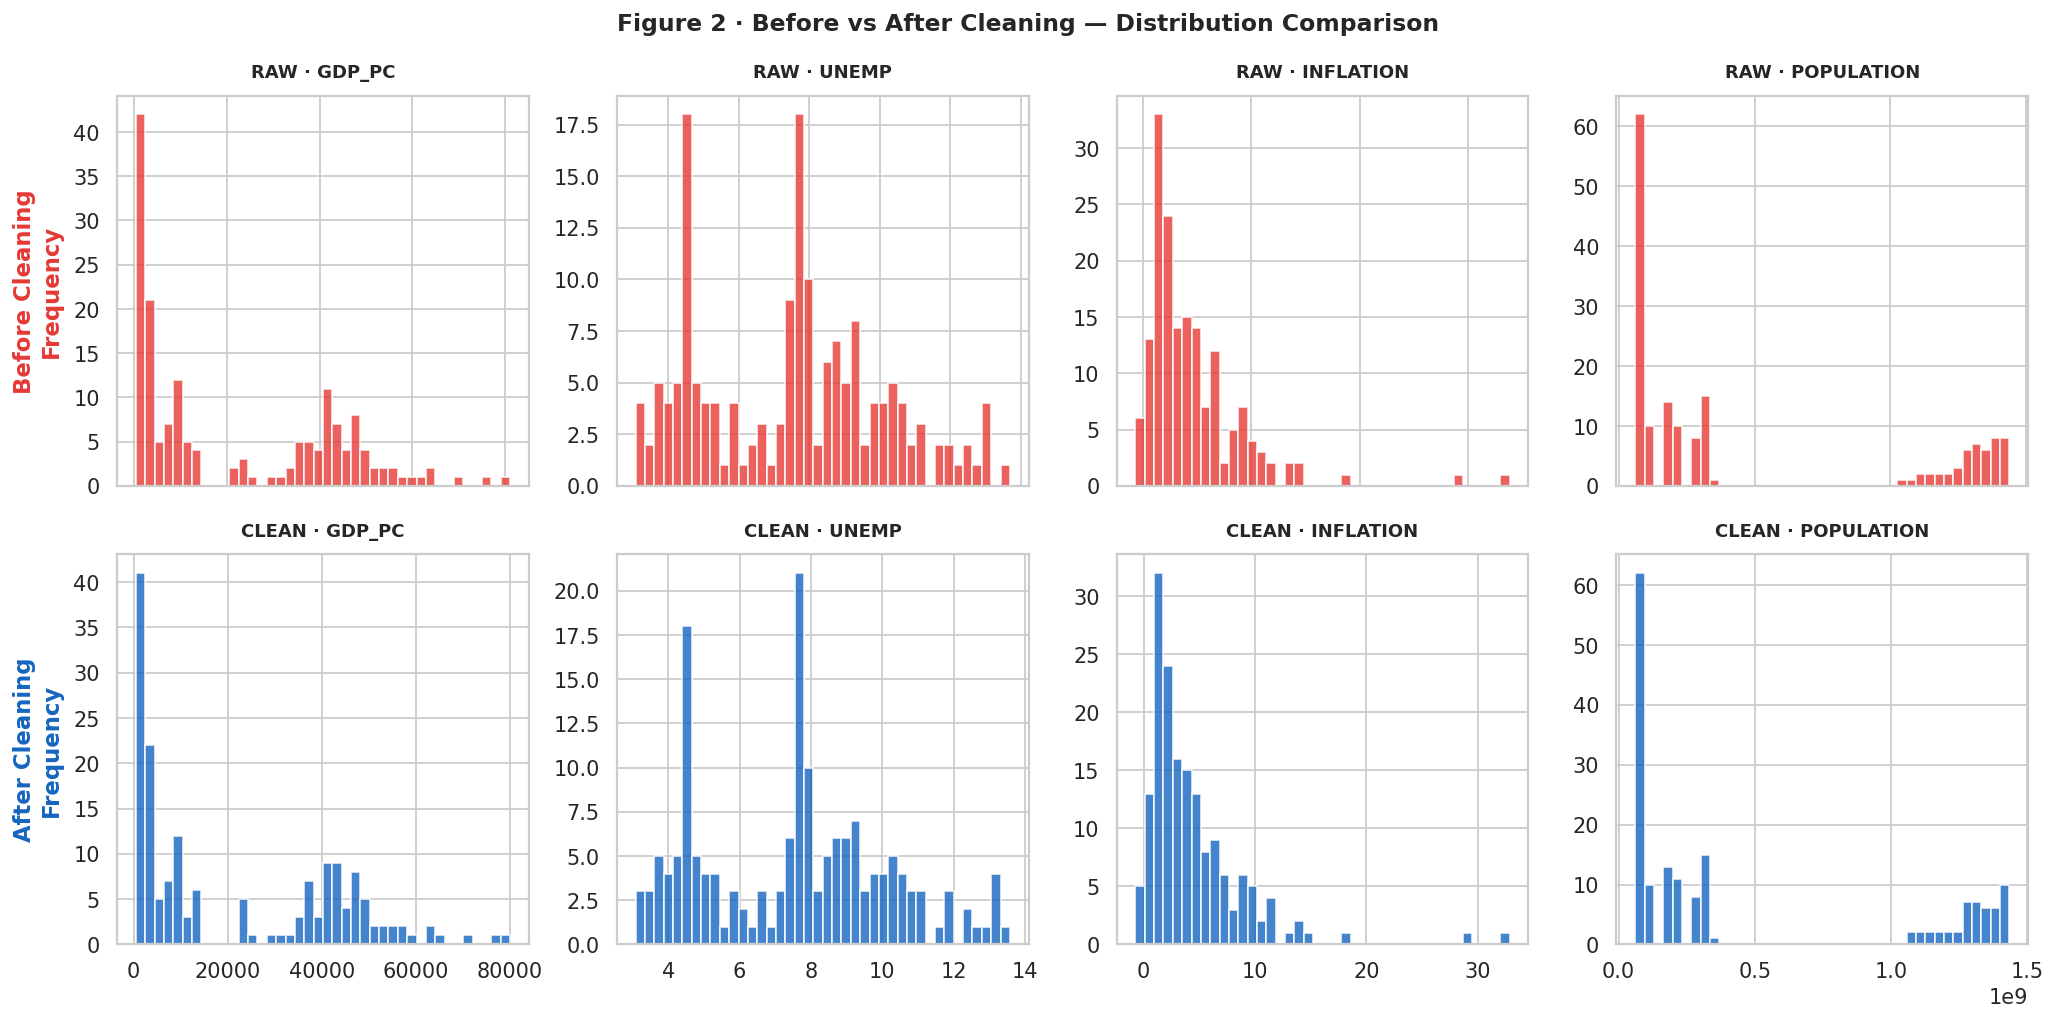

In [ ]:
# ── Before vs After Cleaning ────────────────────────────────────────
indicators_plot = [c for c in list(cfg.indicators.keys()) if c in df_clean.columns][:4]

fig, axes = plt.subplots(2, len(indicators_plot), figsize=(16, 8))

for i, col in enumerate(indicators_plot):
    raw_vals   = df_raw[df_raw["indicator_name"] == col]["value"].dropna()
    clean_vals = df_clean[col].dropna()

    axes[0, i].hist(raw_vals, bins=40, color=PALETTE[1], alpha=0.8, edgecolor="white")
    axes[0, i].set_title(f"RAW \u00b7 {col}", fontweight="bold", fontsize=10)
    axes[0, i].set_ylabel("Frequency" if i == 0 else "")
    axes[0, i].tick_params(labelbottom=False)

    axes[1, i].hist(clean_vals, bins=40, color=PALETTE[0], alpha=0.8, edgecolor="white")
    axes[1, i].set_title(f"CLEAN \u00b7 {col}", fontweight="bold", fontsize=10)
    axes[1, i].set_ylabel("Frequency" if i == 0 else "")

for ax, label, col in zip(axes[:, 0], ["Before Cleaning", "After Cleaning"],
                           [PALETTE[1], PALETTE[0]]):
    ax.set_ylabel(f"{label}\nFrequency", color=col, fontweight="bold")

plt.suptitle("Figure 2 · Before vs After Cleaning — Distribution Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig2_before_after_cleaning.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 4 · Feature Engineering  (ETL: **Transform** — Stage II)

Raw indicator values differ by several orders of magnitude (Population ~10⁹ vs Unemployment ~5%).  
Effective mining requires both **derived features** (domain knowledge) and **standardised scales**.

| Feature | Formula | Interpretation |
|---------|---------|----------------|
| `GDP_LOG` | log₁₀(GDP_PC + 1) | Log-compresses right-skewed GDP distribution |
| `ECON_STABILITY` | GDP_PC / (UNEMP + 1) | Combines growth and employment into one score |
| `HUMAN_DEV` | (LIFE_EXP × INTERNET) / 1000 | Proxy for human development composite |
| `GROWTH_RATE` | Year-over-year % change in GDP_PC | Momentum signal; clipped to [−50, +100] to exclude hyperinflation/crash artefacts |
| `HIGH_GDP` | GDP_PC > median → 1, else 0 | Binary classification target |
| `COUNTRY_ENC` | Label-encoded country_code | For tree-based models |

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 4 · Feature Engineering
# ──────────────────────────────────────────────────────────────────

df = df_clean.copy()

# ── Derived features ────────────────────────────────────────────────
if "GDP_PC" in df.columns:
    df["GDP_LOG"]        = np.log10(df["GDP_PC"].clip(lower=1))
    df["ECON_STABILITY"] = df["GDP_PC"] / (df["UNEMP"].clip(lower=0.1) + 1)

if "LIFE_EXP" in df.columns and "INTERNET" in df.columns:
    df["HUMAN_DEV"] = (df["LIFE_EXP"] * df["INTERNET"]) / 1000

# ── GDP growth rate (per country) ───────────────────────────────────
# Clipped to [-50, +100]: excludes post-war reconstruction spikes and
# data-entry artefacts while preserving all economically plausible swings.
if "GDP_PC" in df.columns:
    df = df.sort_values(["country_code", "year"])
    df["GROWTH_RATE"] = (df.groupby("country_code")["GDP_PC"]
                           .pct_change() * 100)
    df["GROWTH_RATE"] = df["GROWTH_RATE"].fillna(0).clip(-50, 100)

# ── Categorical encoding ─────────────────────────────────────────────
le = LabelEncoder()
df["COUNTRY_ENC"] = le.fit_transform(df["country_code"])

# ── Classification target ────────────────────────────────────────────
if "GDP_PC" in df.columns:
    median_gdp  = df["GDP_PC"].median()
    df["HIGH_GDP"] = (df["GDP_PC"] > median_gdp).astype(int)
    print(f"Classification target  \u2192  HIGH_GDP")
    print(f"  Median GDP per capita: ${median_gdp:,.0f}")
    print(f"  Class distribution   : {df['HIGH_GDP'].value_counts().to_dict()}")

# ── Standardisation ──────────────────────────────────────────────────
numeric_base = [c for c in ["GDP_PC","UNEMP","INFLATION","POPULATION",
                             "LIFE_EXP","INTERNET"] if c in df.columns]
feature_cols = [c for c in numeric_base + ["GDP_LOG","ECON_STABILITY",
                "HUMAN_DEV","GROWTH_RATE"] if c in df.columns]

scaler    = RobustScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f"\nFeature matrix shape  :  {df_scaled[feature_cols].shape}")
print(f"Features              :  {', '.join(feature_cols)}")
df[feature_cols + ["country_code","year","HIGH_GDP"]].describe().round(3)

Classification target  →  HIGH_GDP
  Median GDP per capita: $10,083
  Class distribution   : {0: 84, 1: 84}

Feature matrix shape  :  (168, 10)
Features              :  GDP_PC, UNEMP, INFLATION, POPULATION, LIFE_EXP, INTERNET, GDP_LOG, ECON_STABILITY, HUMAN_DEV, GROWTH_RATE


,GDP_PC,UNEMP,INFLATION,POPULATION,LIFE_EXP,INTERNET,GDP_LOG,ECON_STABILITY,HUMAN_DEV,GROWTH_RATE,year,HIGH_GDP
count,168.000,168.000,168.000,1.680000e+02,168.000,168.000,168.000,168.000,168.000,168.000,168.000,168.000
mean,21542.868,7.530,4.481,4.799062e+08,75.056,49.729,3.976,3076.871,3.855,5.709,2011.500,0.500
std,21285.446,2.605,4.546,5.326489e+08,5.166,30.155,0.650,3701.511,2.435,10.181,6.943,0.501
min,444.500,3.086,-0.731,6.102118e+07,62.843,0.558,2.648,51.752,0.035,-27.200,2000.000,0.000
25%,2477.298,4.857,1.642,8.236982e+07,70.432,20.061,3.394,248.271,1.405,0.000,2005.750,0.000
50%,10083.086,7.632,3.201,1.960804e+08,76.044,53.750,4.004,1465.825,4.044,4.809,2011.500,0.500
75%,41778.505,9.256,6.011,1.159227e+09,78.966,77.415,4.621,4655.090,5.991,12.319,2017.250,1.000
max,80026.009,13.573,32.878,1.435161e+09,82.831,93.342,4.903,17244.160,7.479,31.769,2023.000,1.000


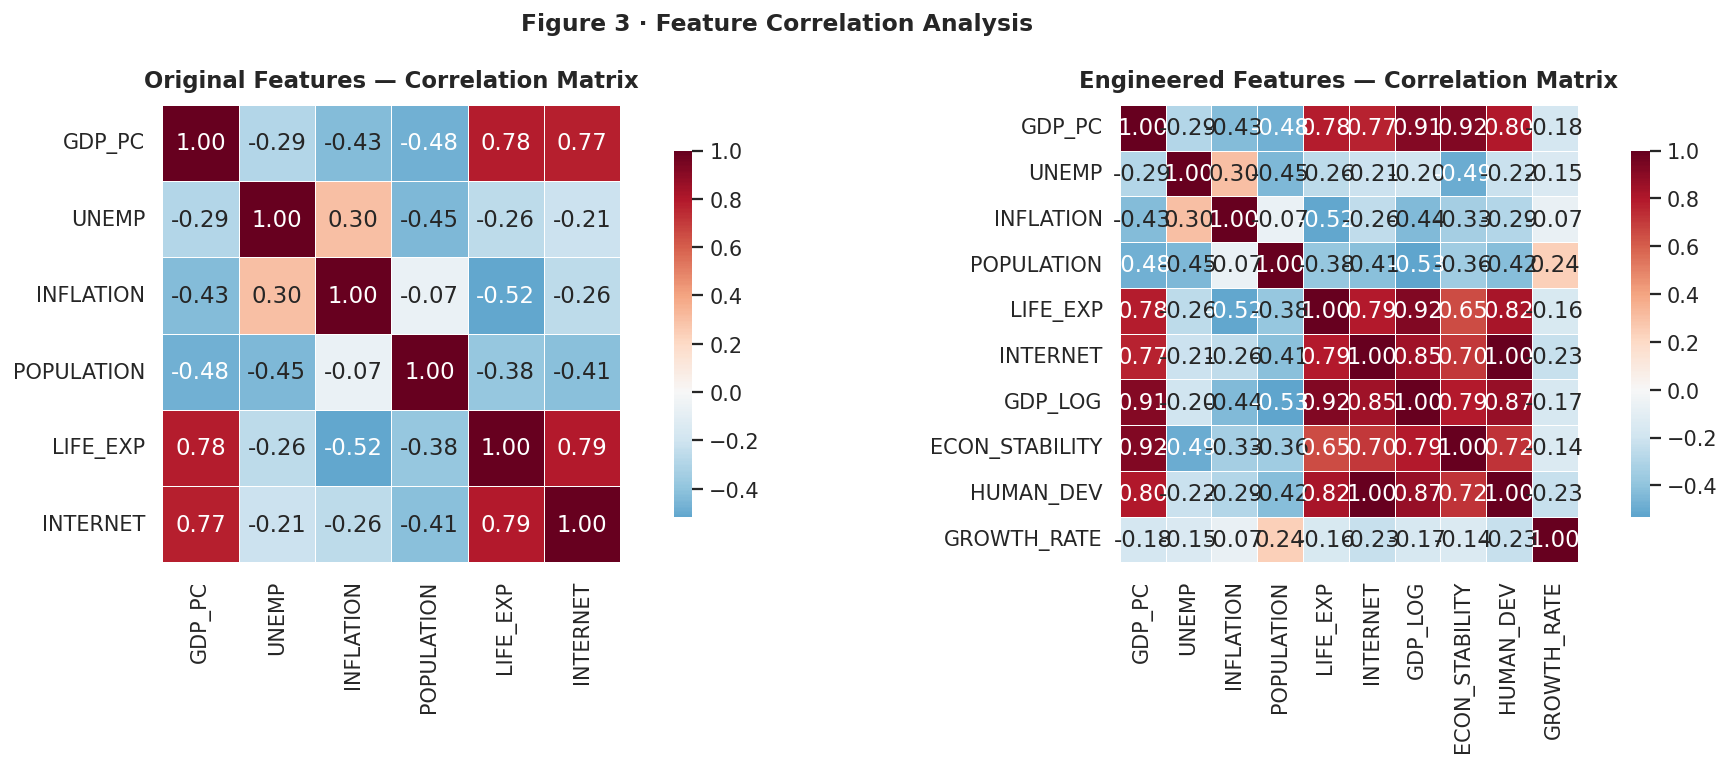

In [ ]:
# ── Correlation heatmap (post-engineering) ───────────────────────────
corr_cols = [c for c in feature_cols if c in df.columns]
corr      = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(numeric_base) >= 2:
    sns.heatmap(df[numeric_base].corr(), annot=True, fmt=".2f",
                cmap="RdBu_r", center=0, square=True,
                linewidths=0.5, ax=axes[0], cbar_kws={"shrink": 0.8})
    axes[0].set_title("Original Features \u2014 Correlation Matrix", fontweight="bold")

sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Engineered Features \u2014 Correlation Matrix", fontweight="bold")

plt.suptitle("Figure 3 · Feature Correlation Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig3_correlation.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 5 · Exploratory Data Analysis

Time-series trends and country-level comparisons before mining. Key historical events are annotated for economic context.

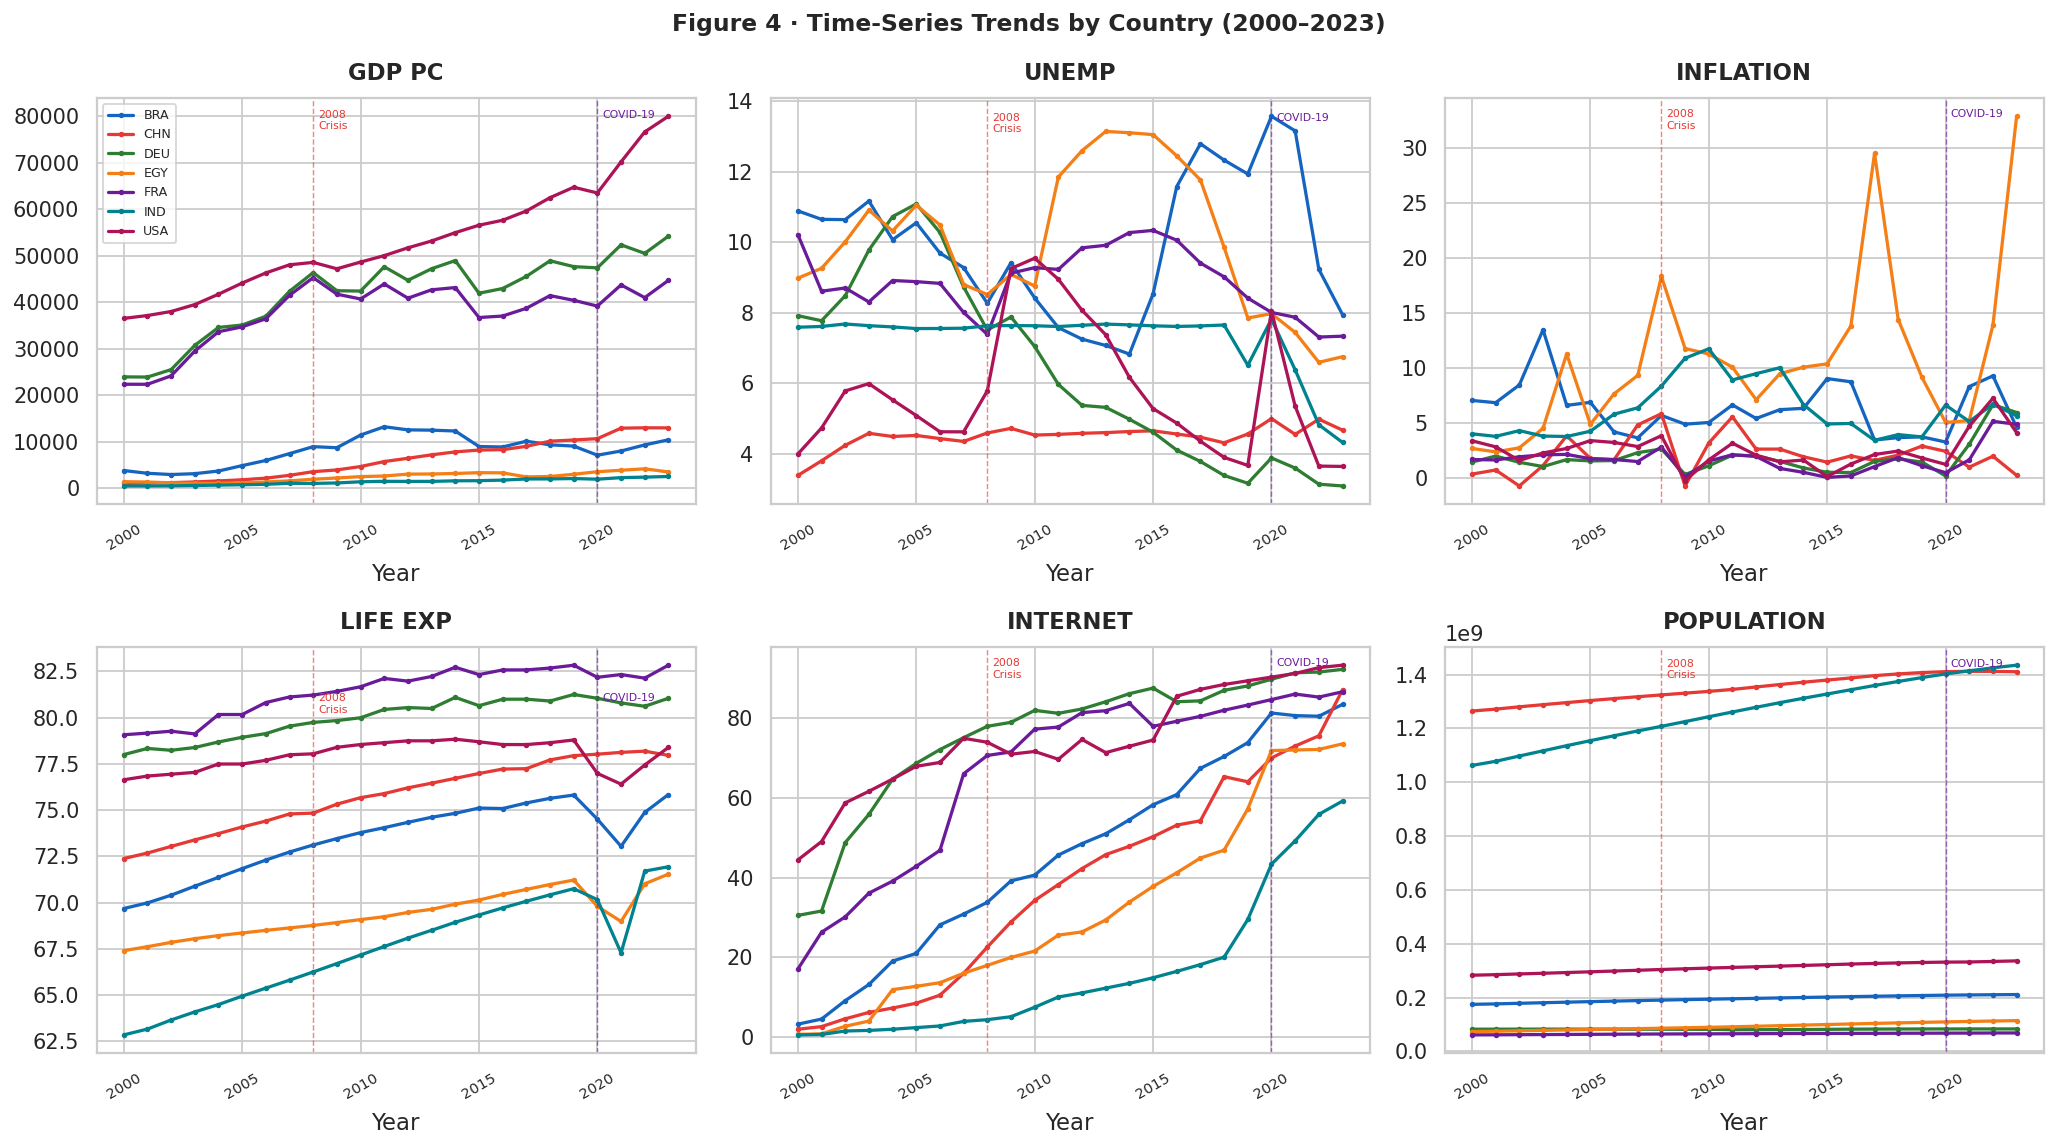

In [ ]:
# ── Time-series: All Indicators by Country ─────────────────────────
# Key economic events annotated for interpretive context
EVENT_LINES = {
    2008: ("2008\nCrisis", PALETTE[1]),
    2020: ("COVID-19", PALETTE[4]),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

plot_indicators = [c for c in ["GDP_PC","UNEMP","INFLATION",
                                "LIFE_EXP","INTERNET","POPULATION"]
                   if c in df.columns]

for idx, col in enumerate(plot_indicators):
    ax = axes[idx]
    for jdx, (country, grp) in enumerate(df.groupby("country_code")):
        grp_sorted = grp.sort_values("year")
        ax.plot(grp_sorted["year"], grp_sorted[col],
                marker="o", markersize=2, linewidth=1.8,
                label=country, color=PALETTE[jdx % len(PALETTE)])
    # Annotate key events
    for yr, (label, color) in EVENT_LINES.items():
        ax.axvline(yr, color=color, linestyle="--", linewidth=0.8, alpha=0.6)
        ax.text(yr + 0.2, ax.get_ylim()[1] * 0.97, label,
                color=color, fontsize=6, va="top")
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_xlabel("Year")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")

for ax in axes[len(plot_indicators):]:
    ax.set_visible(False)

plt.suptitle("Figure 4 · Time-Series Trends by Country (2000\u20132023)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig4_time_series.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 6 · Clustering Analysis

### Algorithm: K-Means with PCA + UMAP + Radar Profile

**Methodology:**
1. Select standardised numeric features
2. Determine optimal *k* via Elbow (inertia) AND Silhouette coefficient — using a **consistent `n_init`** value
3. Fit K-Means with optimal *k*
4. Project to 2D via PCA (linear) and UMAP (non-linear, topology-preserving)
5. Profile each cluster via mean indicator values **and a radar chart** for visual comparison

Evaluating k:   0%|          | 0/7 [00:00<?, ?it/s]

Best silhouette score : 0.4099 at k=2
Chosen k              : 4  (set in PipelineConfig)


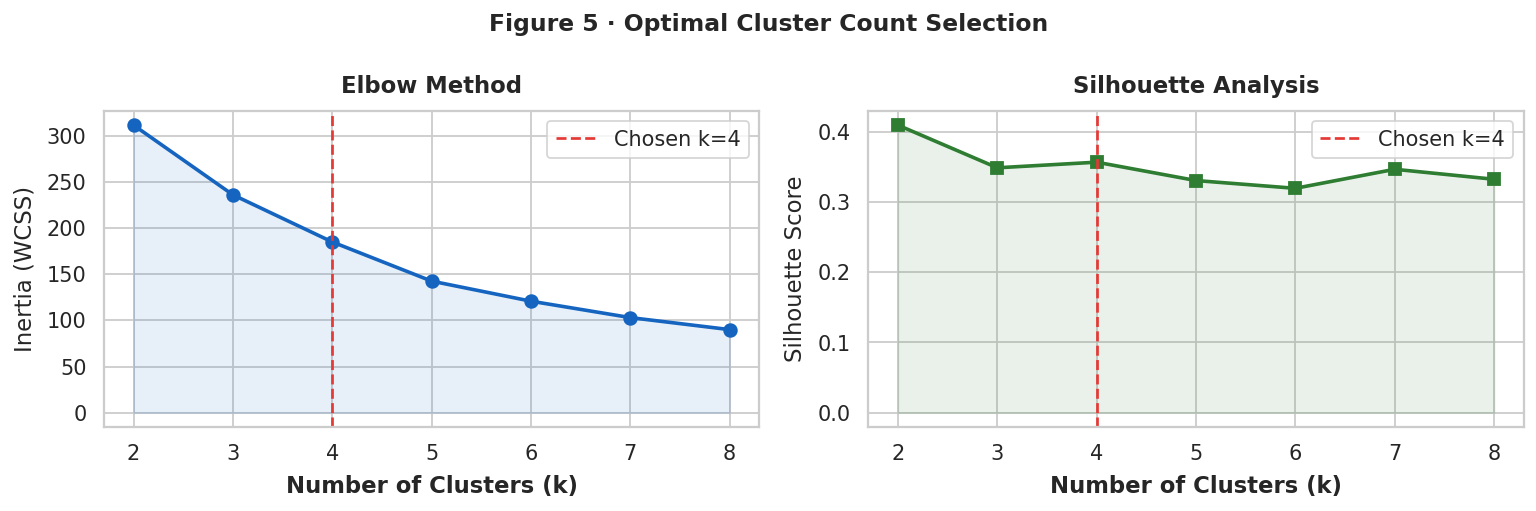

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 6 · Clustering
# ──────────────────────────────────────────────────────────────────

cluster_features = [c for c in ["GDP_PC","UNEMP","INFLATION",
                                 "LIFE_EXP","INTERNET","ECON_STABILITY",
                                 "HUMAN_DEV"] if c in df_scaled.columns]

X_clust   = df_scaled[cluster_features].dropna().values
idx_valid = df_scaled[cluster_features].dropna().index

# ── Optimal k: Elbow + Silhouette ────────────────────────────────────
# cfg.kmeans_n_init is used here AND in the final fit for consistency.
k_range    = range(2, 9)
inertias, silhouettes = [], []

for k in tqdm(k_range, desc="Evaluating k"):
    km     = KMeans(n_clusters=k, random_state=cfg.random_state,
                    n_init=cfg.kmeans_n_init)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, "o-", color=PALETTE[0], linewidth=2, markersize=7)
ax1.fill_between(k_range, inertias, alpha=0.1, color=PALETTE[0])
ax1.set_xlabel("Number of Clusters (k)", fontweight="bold")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method", fontweight="bold")
ax1.axvline(x=cfg.n_clusters, color=PALETTE[1], linestyle="--",
            label=f"Chosen k={cfg.n_clusters}")
ax1.legend()

ax2.plot(k_range, silhouettes, "s-", color=PALETTE[2], linewidth=2, markersize=7)
ax2.fill_between(k_range, silhouettes, alpha=0.1, color=PALETTE[2])
ax2.set_xlabel("Number of Clusters (k)", fontweight="bold")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis", fontweight="bold")
ax2.axvline(x=cfg.n_clusters, color=PALETTE[1], linestyle="--",
            label=f"Chosen k={cfg.n_clusters}")
ax2.legend()

best_sil_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"Best silhouette score : {max(silhouettes):.4f} at k={best_sil_k}")
print(f"Chosen k              : {cfg.n_clusters}  (set in PipelineConfig)")

plt.suptitle("Figure 5 · Optimal Cluster Count Selection",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig5_elbow_silhouette.png",
            bbox_inches="tight", dpi=150)
plt.show()

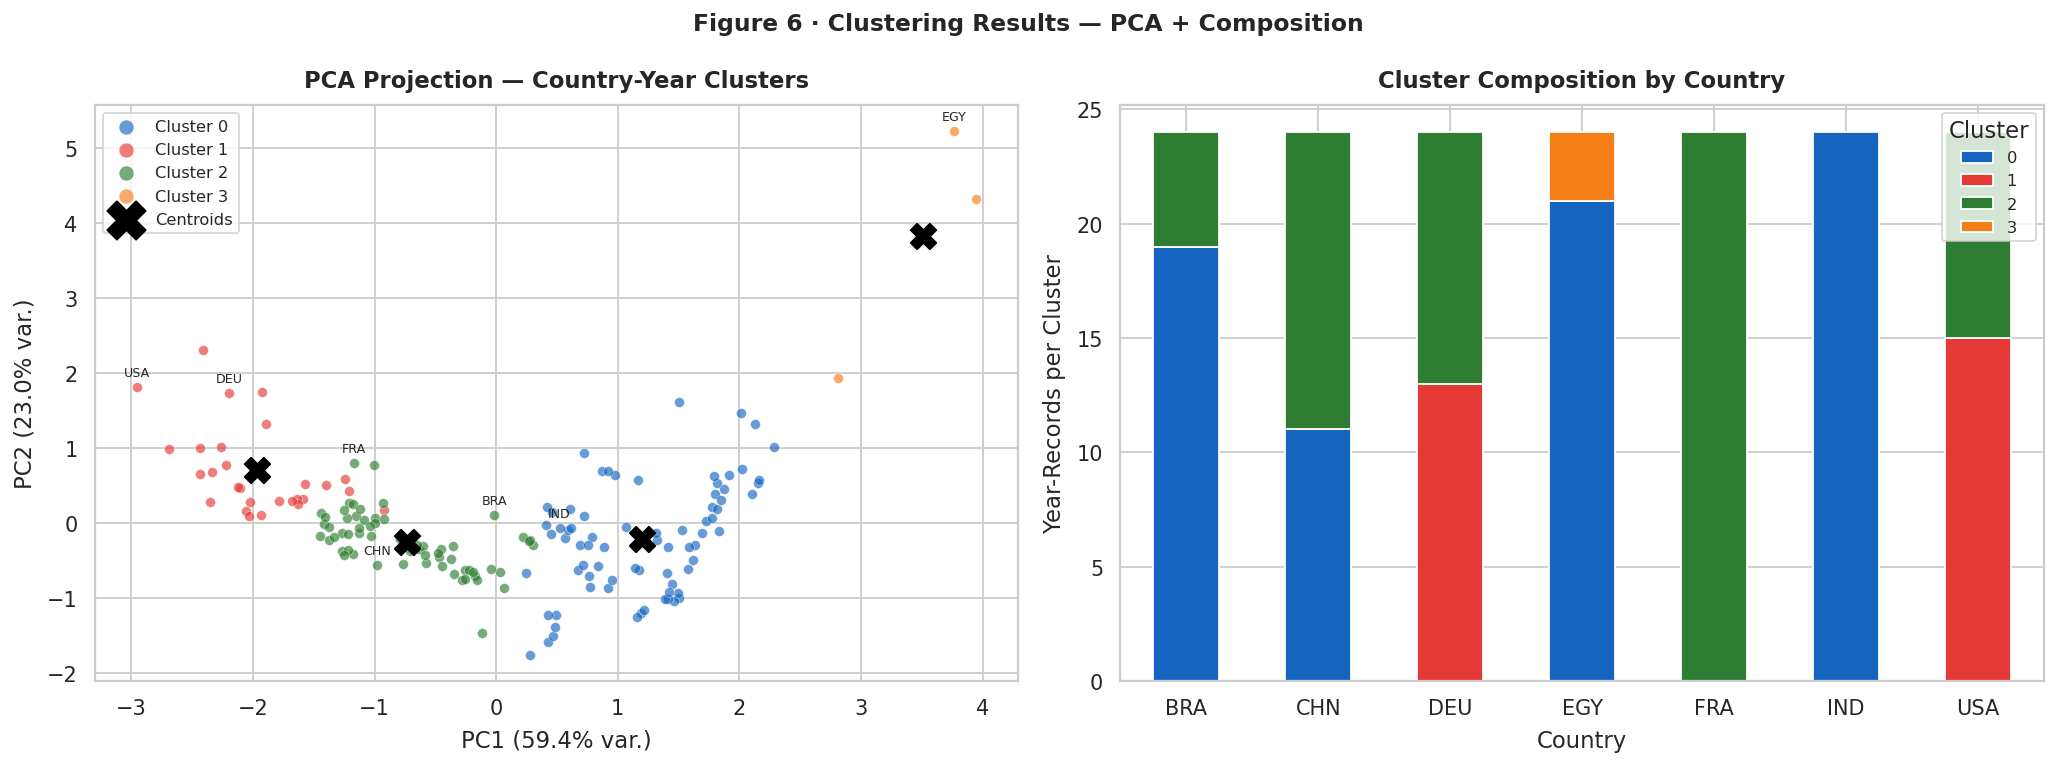


Silhouette score (final k=4): 0.3571
PCA explained variance (PC1+PC2): 82.4%


In [ ]:
# ── Fit final K-Means ────────────────────────────────────────────────
kmeans = KMeans(n_clusters=cfg.n_clusters, random_state=cfg.random_state,
                n_init=cfg.kmeans_n_init)
cluster_labels = kmeans.fit_predict(X_clust)
df_clust = df_scaled.loc[idx_valid].copy()
df_clust["cluster"] = cluster_labels

# ── PCA 2-D projection ───────────────────────────────────────────────
pca       = PCA(n_components=2, random_state=cfg.random_state)
pca_coords = pca.fit_transform(X_clust)
df_clust["PC1"] = pca_coords[:, 0]
df_clust["PC2"] = pca_coords[:, 1]

# ── Plot PCA ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for k in range(cfg.n_clusters):
    mask = df_clust["cluster"] == k
    axes[0].scatter(df_clust.loc[mask, "PC1"],
                    df_clust.loc[mask, "PC2"],
                    c=PALETTE[k], alpha=0.65, s=30, edgecolors="white",
                    linewidth=0.3, label=f"Cluster {k}")
c_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(c_pca[:, 0], c_pca[:, 1], c="black", s=200,
                marker="X", zorder=5, label="Centroids")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
axes[0].set_title("PCA Projection \u2014 Country-Year Clusters", fontweight="bold")
axes[0].legend(markerscale=1.5, fontsize=9)

latest = df_clust.groupby("country_code")["year"].idxmax()
for idx in latest:
    row = df_clust.loc[idx]
    axes[0].annotate(row["country_code"],
                     xy=(row["PC1"], row["PC2"]),
                     fontsize=7, ha="center",
                     xytext=(0, 6), textcoords="offset points")

comp = df_clust.groupby(["cluster","country_code"]).size().unstack(fill_value=0)
comp.T.plot(kind="bar", stacked=True, ax=axes[1],
            color=PALETTE[:cfg.n_clusters], edgecolor="white")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Year-Records per Cluster")
axes[1].set_title("Cluster Composition by Country", fontweight="bold")
axes[1].tick_params(axis="x", labelrotation=0)
axes[1].legend(title="Cluster", fontsize=9)

plt.suptitle("Figure 6 · Clustering Results \u2014 PCA + Composition",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig6_pca_clusters.png",
            bbox_inches="tight", dpi=150)
plt.show()

print(f"\nSilhouette score (final k={cfg.n_clusters}): "
      f"{silhouette_score(X_clust, cluster_labels):.4f}")
print(f"PCA explained variance (PC1+PC2): "
      f"{sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

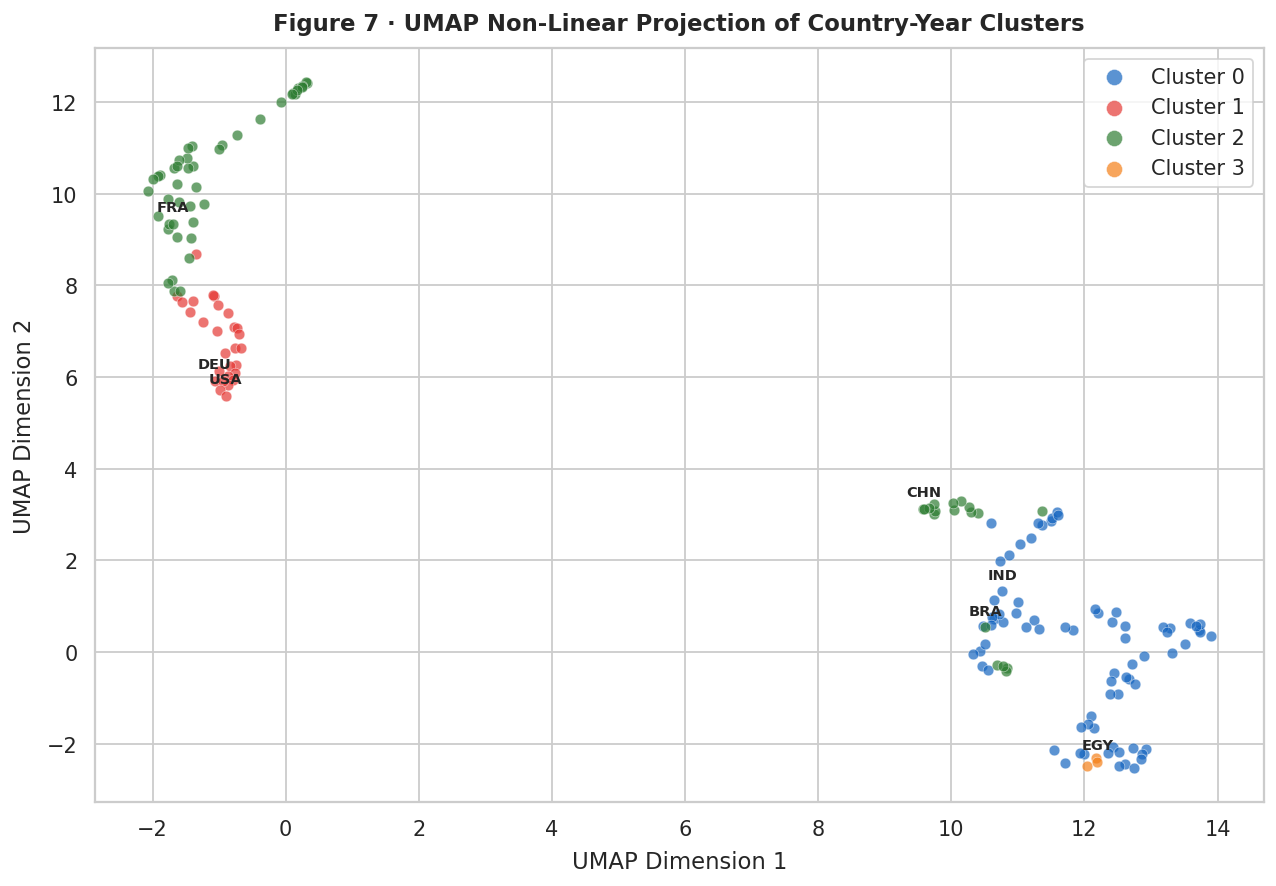


── Cluster Mean Profiles (original scale) ──


,GDP_PC,UNEMP,INFLATION,LIFE_EXP,INTERNET
cluster,,,,,
0,-0.17,0.13,0.75,-0.67,-0.50
1,1.10,-0.70,-0.15,0.38,0.51
2,0.51,0.08,-0.30,0.36,0.19
3,-0.19,0.31,5.42,-0.67,-0.14


In [ ]:
# ── UMAP visualisation ──────────────────────────────────────────────
if UMAP_AVAILABLE:
    reducer    = umap.UMAP(n_components=2, random_state=cfg.random_state,
                            n_neighbors=15, min_dist=0.1)
    umap_coords = reducer.fit_transform(X_clust)
    df_clust["U1"] = umap_coords[:, 0]
    df_clust["U2"] = umap_coords[:, 1]

    fig, ax = plt.subplots(figsize=(10, 7))
    for k in range(cfg.n_clusters):
        mask = df_clust["cluster"] == k
        ax.scatter(df_clust.loc[mask, "U1"], df_clust.loc[mask, "U2"],
                   c=PALETTE[k], alpha=0.7, s=35, edgecolors="white",
                   linewidth=0.3, label=f"Cluster {k}")
    for idx in latest:
        row = df_clust.loc[idx]
        ax.annotate(row["country_code"],
                    xy=(row["U1"], row["U2"]),
                    fontsize=8, ha="center",
                    xytext=(0, 7), textcoords="offset points",
                    fontweight="bold")
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.set_title("Figure 7 · UMAP Non-Linear Projection of Country-Year Clusters",
                 fontweight="bold")
    ax.legend(markerscale=1.5)
    plt.tight_layout()
    plt.savefig(f"{cfg.data_dir}/fig7_umap_clusters.png",
                bbox_inches="tight", dpi=150)
    plt.show()
else:
    print("UMAP skipped \u2014 install umap-learn for non-linear projection.")

# ── Cluster profiles ─────────────────────────────────────────────────
orig_features = [c for c in ["GDP_PC","UNEMP","INFLATION",
                              "LIFE_EXP","INTERNET"] if c in df_clust.columns]
profile_df    = df_clust.groupby("cluster")[orig_features].mean().round(2)
print("\n\u2500\u2500 Cluster Mean Profiles (original scale) \u2500\u2500")
display(profile_df.style
        .background_gradient(cmap="Blues", axis=0)
        .format("{:.2f}"))

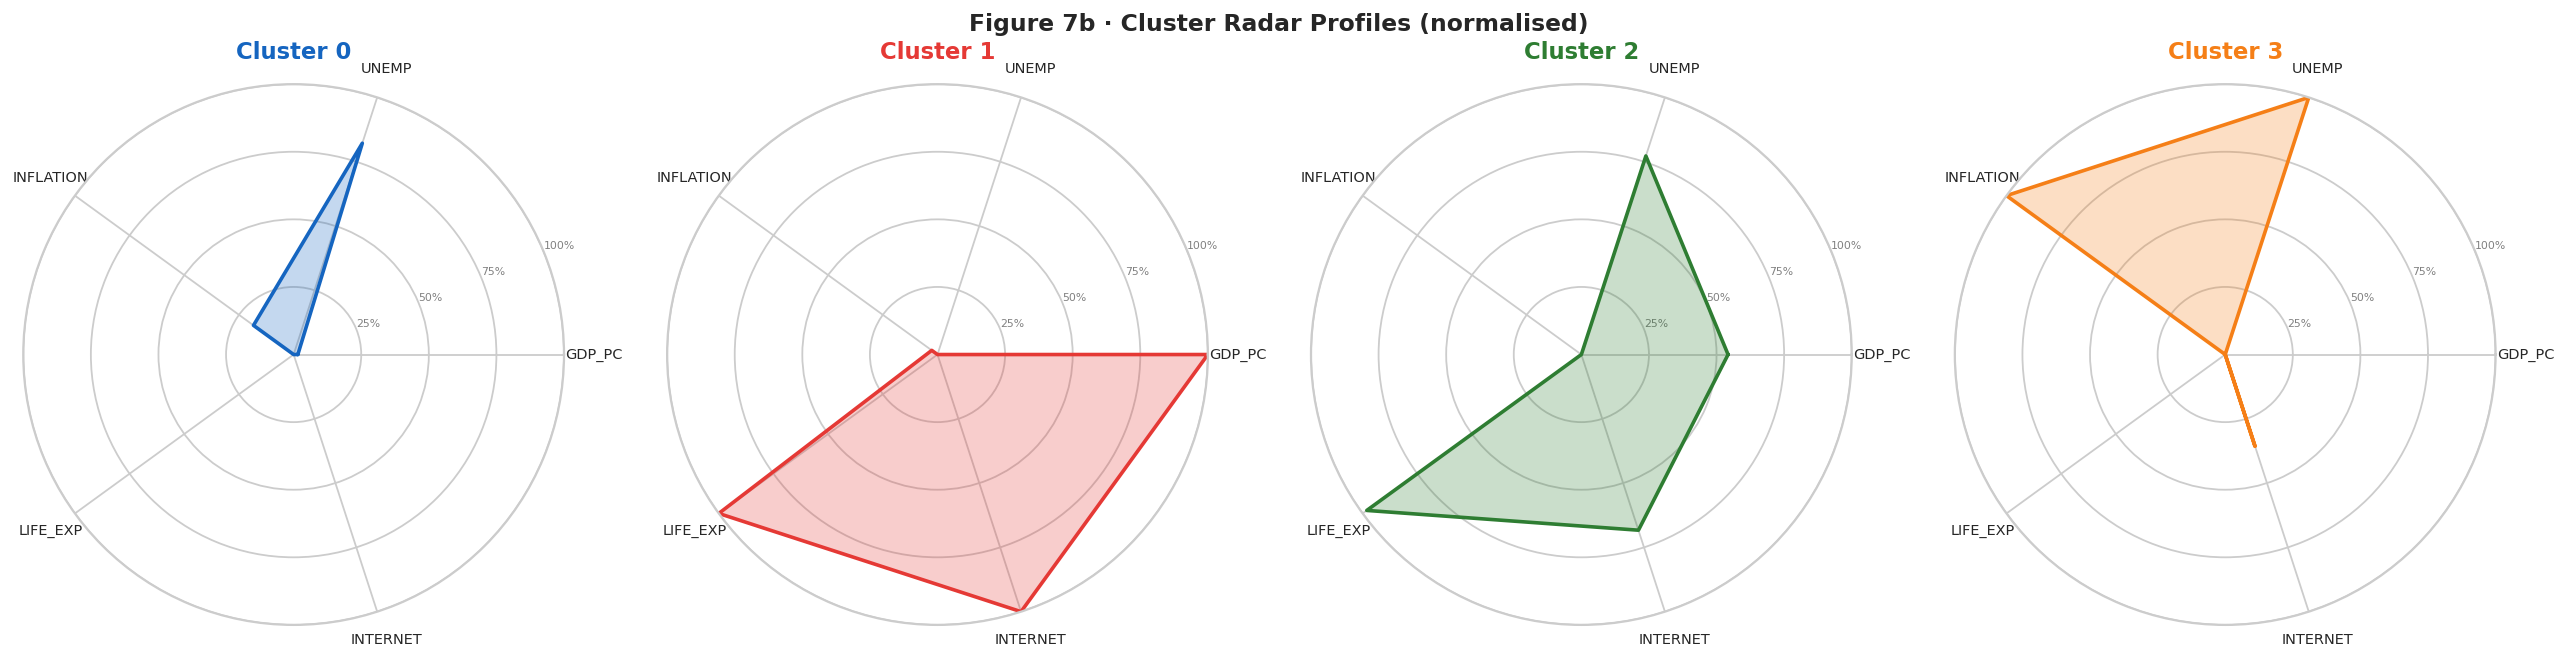

In [ ]:
# ── Radar chart: cluster profiles ───────────────────────────────────
# Normalise each feature to [0, 1] so all axes are comparable
profile_norm = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min() + 1e-9)

labels  = profile_norm.columns.tolist()
N       = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, cfg.n_clusters,
                          figsize=(5 * cfg.n_clusters, 5),
                          subplot_kw=dict(polar=True))

for k, ax in enumerate(axes):
    values  = profile_norm.loc[k].tolist() + profile_norm.loc[k].tolist()[:1]
    ax.plot(angles, values, color=PALETTE[k], linewidth=2)
    ax.fill(angles, values, color=PALETTE[k], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticks([0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=6, color="grey")
    ax.set_title(f"Cluster {k}", fontweight="bold", pad=14, color=PALETTE[k])
    ax.set_ylim(0, 1)

plt.suptitle("Figure 7b · Cluster Radar Profiles (normalised)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig7b_radar_profiles.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 7 · Frequent Pattern Mining

### Algorithm: Apriori + FP-Growth

Economic indicators are discretised into **HIGH binary flags only** (above median).  
Using only `_HIGH` flags — not complementary `_LOW` pairs — prevents trivially obvious rules  
(e.g. `GDP_HIGH → UNEMP_LOW`) that merely restate the definition of complementary columns.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Support | P(A ∪ B) | How often the itemset appears |
| Confidence | P(B \| A) | Reliability of the rule A→B |
| Lift | conf / P(B) | Surprise relative to baseline |
| Conviction | (1−P(B))/(1−conf) | Strength of implication |

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 7 · Frequent Pattern Mining
# ──────────────────────────────────────────────────────────────────

# ── Discretise indicators into HIGH binary flags only ───────────────
# KEY FIX: Using only _HIGH flags avoids trivially anti-correlated rules.
# e.g. if both GDP_HIGH and GDP_LOW existed, the rule "GDP_HIGH → ~GDP_LOW"
# would appear with perfect confidence and lift > 1 but conveys zero information.
df_mine = df.copy()

for col in [c for c in ["GDP_PC","UNEMP","INFLATION","LIFE_EXP","INTERNET",
                          "ECON_STABILITY","GROWTH_RATE"] if c in df_mine.columns]:
    med = df_mine[col].median()
    df_mine[f"{col}_HIGH"] = (df_mine[col] >= med)

bool_cols = [c for c in df_mine.columns if c.endswith("_HIGH")]
basket    = df_mine[bool_cols].astype(bool)

print(f"Transaction matrix shape : {basket.shape}")
print(f"Binary features          : {bool_cols}")

# ── Apriori ──────────────────────────────────────────────────────────
freq_items = apriori(basket, min_support=cfg.min_support, use_colnames=True)
rules      = association_rules(freq_items,
                                metric="confidence",
                                min_threshold=cfg.min_confidence)
rules      = rules[rules["lift"] >= cfg.min_lift].sort_values("lift", ascending=False)

# ── FP-Growth (cross-validate) ───────────────────────────────────────
freq_fp   = fpgrowth(basket, min_support=cfg.min_support, use_colnames=True)
rules_fp  = association_rules(freq_fp,
                               metric="confidence",
                               min_threshold=cfg.min_confidence)
rules_fp  = rules_fp[rules_fp["lift"] >= cfg.min_lift].sort_values("lift", ascending=False)

print(f"\nApriori   \u2192  {len(freq_items):>4} frequent itemsets, {len(rules):>3} rules")
print(f"FP-Growth \u2192  {len(freq_fp):>4} frequent itemsets, {len(rules_fp):>3} rules")
assert len(rules) == len(rules_fp), "\u26a0\ufe0f  Apriori/FP-Growth rule counts differ \u2014 check thresholds"

# ── Top 10 rules ─────────────────────────────────────────────────────
top10 = rules.head(10)[["antecedents","consequents",
                          "support","confidence","lift","conviction"]].copy()
top10["antecedents"] = top10["antecedents"].apply(lambda x: ", ".join(list(x)))
top10["consequents"] = top10["consequents"].apply(lambda x: ", ".join(list(x)))
top10 = top10.round(4)
display(top10.style
        .background_gradient(subset=["lift","confidence"], cmap="Greens")
        .format({"support":"{:.3f}","confidence":"{:.3f}",
                 "lift":"{:.3f}","conviction":"{:.3f}"}))

Transaction matrix shape : (168, 7)
Binary features          : ['GDP_PC_HIGH', 'UNEMP_HIGH', 'INFLATION_HIGH', 'LIFE_EXP_HIGH', 'INTERNET_HIGH', 'ECON_STABILITY_HIGH', 'GROWTH_RATE_HIGH']

Apriori   →    20 frequent itemsets,  50 rules
FP-Growth →    20 frequent itemsets,  50 rules


,antecedents,consequents,support,confidence,lift,conviction
40,"GDP_PC_HIGH, LIFE_EXP_HIGH","ECON_STABILITY_HIGH, INTERNET_HIGH",0.393,0.846,2.091,3.869
45,"ECON_STABILITY_HIGH, INTERNET_HIGH","GDP_PC_HIGH, LIFE_EXP_HIGH",0.393,0.971,2.091,18.214
42,"GDP_PC_HIGH, INTERNET_HIGH","LIFE_EXP_HIGH, ECON_STABILITY_HIGH",0.393,0.971,2.038,17.809
43,"LIFE_EXP_HIGH, ECON_STABILITY_HIGH","GDP_PC_HIGH, INTERNET_HIGH",0.393,0.825,2.038,3.401
44,"LIFE_EXP_HIGH, INTERNET_HIGH","GDP_PC_HIGH, ECON_STABILITY_HIGH",0.393,0.985,2.018,34.298
41,"GDP_PC_HIGH, ECON_STABILITY_HIGH","LIFE_EXP_HIGH, INTERNET_HIGH",0.393,0.805,2.018,3.081
23,ECON_STABILITY_HIGH,"GDP_PC_HIGH, LIFE_EXP_HIGH",0.464,0.929,2.000,7.500
18,"GDP_PC_HIGH, LIFE_EXP_HIGH",ECON_STABILITY_HIGH,0.464,1.000,2.000,inf
34,ECON_STABILITY_HIGH,"LIFE_EXP_HIGH, INTERNET_HIGH",0.399,0.798,2.000,2.971
37,"GDP_PC_HIGH, LIFE_EXP_HIGH, INTERNET_HIGH",ECON_STABILITY_HIGH,0.393,1.000,2.000,inf


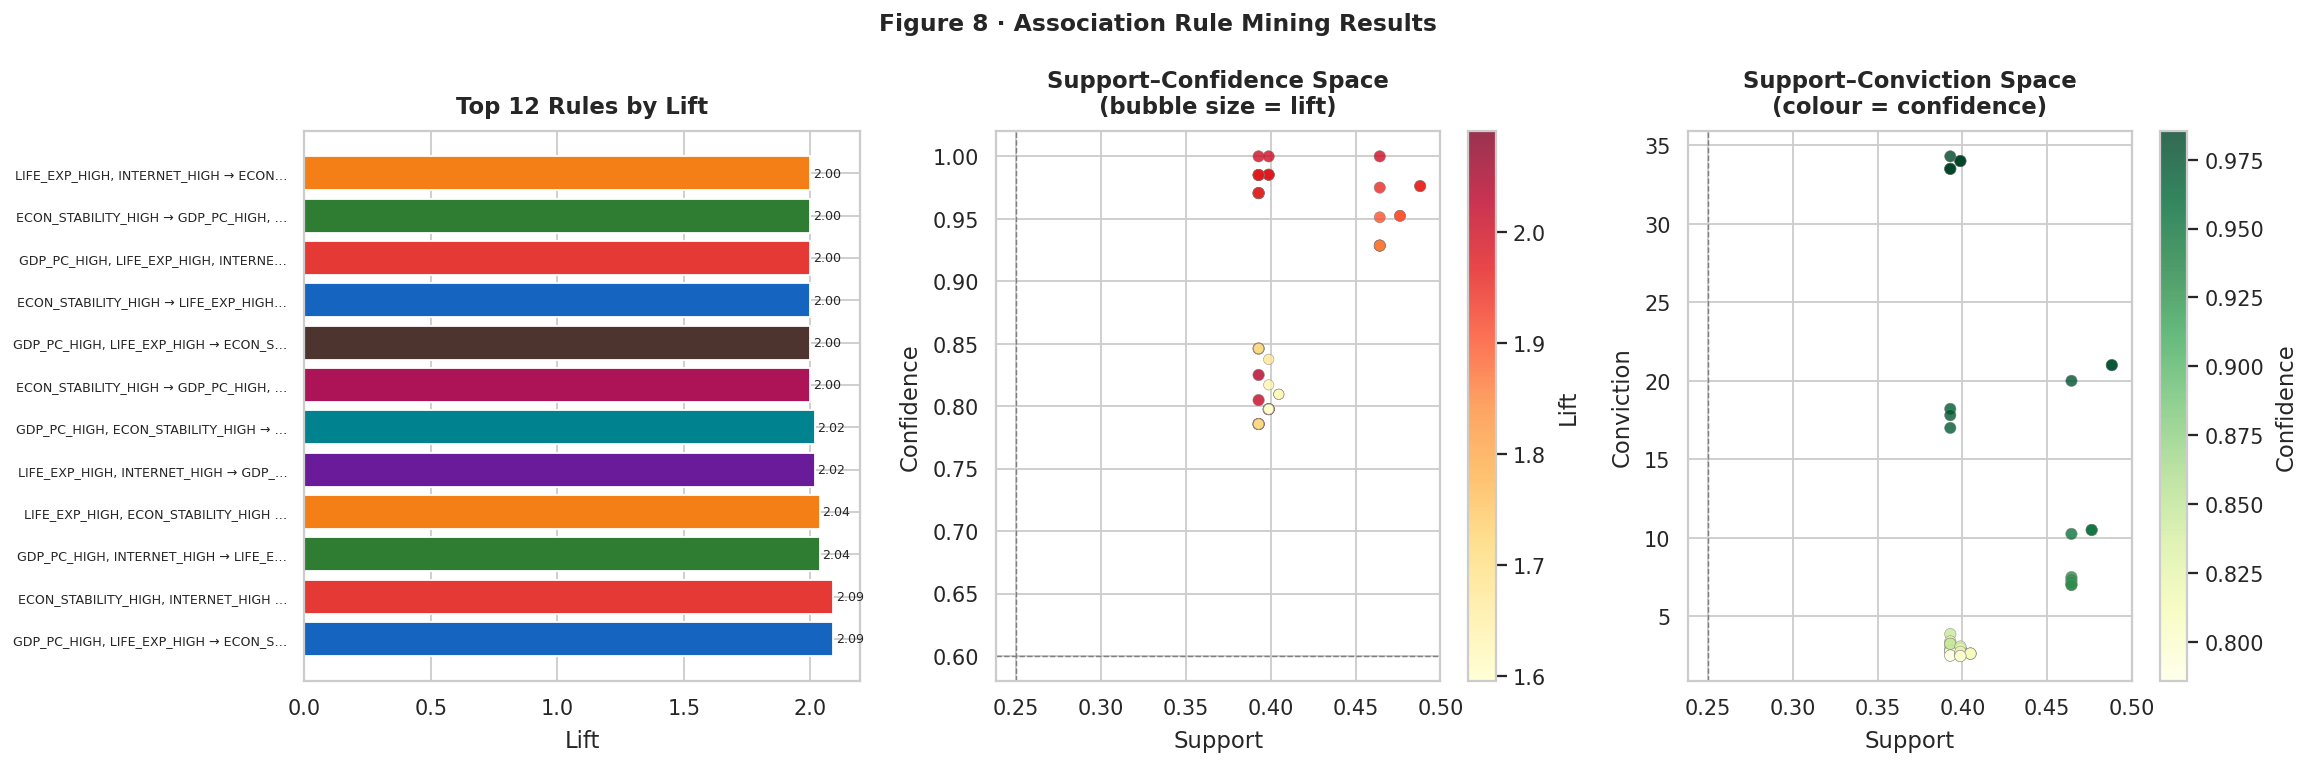

In [ ]:
# ── Association rules visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A \u2014 Top rules by Lift (bar)
top_n = min(12, len(rules))
top_rules_bar = rules.head(top_n).copy()
labels = [f"{', '.join(list(a))} \u2192 {', '.join(list(c))}"
          for a, c in zip(top_rules_bar["antecedents"],
                          top_rules_bar["consequents"])]
short_labels = [l[:35] + "\u2026" if len(l) > 35 else l for l in labels]
bars = axes[0].barh(range(top_n), top_rules_bar["lift"].values,
                    color=PALETTE[:top_n], edgecolor="white")
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(short_labels, fontsize=7)
axes[0].set_xlabel("Lift")
axes[0].set_title(f"Top {top_n} Rules by Lift", fontweight="bold")
for bar, val in zip(bars, top_rules_bar["lift"].values):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", va="center", fontsize=7)

# Panel B \u2014 Support vs Confidence scatter (size = lift)
sc = axes[1].scatter(rules["support"], rules["confidence"],
                     c=rules["lift"], cmap="YlOrRd",
                     s=rules["lift"] * 20, alpha=0.8,
                     edgecolors="grey", linewidth=0.3)
plt.colorbar(sc, ax=axes[1], label="Lift")
axes[1].set_xlabel("Support")
axes[1].set_ylabel("Confidence")
axes[1].set_title("Support\u2013Confidence Space\n(bubble size = lift)", fontweight="bold")
axes[1].axhline(cfg.min_confidence, color="grey", linestyle="--", linewidth=0.8)
axes[1].axvline(cfg.min_support,    color="grey", linestyle="--", linewidth=0.8)

# Panel C \u2014 Support vs Conviction scatter (complements Panel B)
sc2 = axes[2].scatter(rules["support"], rules["conviction"],
                      c=rules["confidence"], cmap="YlGn",
                      s=40, alpha=0.8, edgecolors="grey", linewidth=0.3)
plt.colorbar(sc2, ax=axes[2], label="Confidence")
axes[2].set_xlabel("Support")
axes[2].set_ylabel("Conviction")
axes[2].set_title("Support\u2013Conviction Space\n(colour = confidence)", fontweight="bold")
axes[2].axvline(cfg.min_support, color="grey", linestyle="--", linewidth=0.8)

plt.suptitle("Figure 8 · Association Rule Mining Results",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{cfg.data_dir}/fig8_association_rules.png",
            bbox_inches="tight", dpi=150)
plt.show()

---
## Section 8 · Classification

### Multi-Model Benchmark

Four classifiers are trained and compared under stratified 5-fold cross-validation.  
The target variable `HIGH_GDP` (1 = GDP per capita above median) reflects the binary economic tier of each country-year observation.

| Model | Key Hyperparameters |
|-------|---------------------|
| Random Forest | 300 trees, max_depth=10 |
| Gradient Boosting | 200 estimators, learning_rate=0.05 |
| Logistic Regression | C=1.0, solver=lbfgs, max_iter=1000 |
| Support Vector Machine | RBF kernel, C=1.0, probability=True |

In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 8 · Classification
# ──────────────────────────────────────────────────────────────────

clf_features = [c for c in ["GDP_LOG","UNEMP","INFLATION","LIFE_EXP",
                              "INTERNET","ECON_STABILITY","HUMAN_DEV",
                              "GROWTH_RATE","COUNTRY_ENC"] if c in df_scaled.columns]

df_clf = df_scaled[clf_features + ["HIGH_GDP"]].dropna()
X      = df_clf[clf_features].values
y      = df_clf["HIGH_GDP"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=cfg.test_size,
    random_state=cfg.random_state, stratify=y
)

skf = StratifiedKFold(n_splits=cfg.cv_folds, shuffle=True,
                       random_state=cfg.random_state)

models = {
    "Random Forest":   RandomForestClassifier(n_estimators=300, max_depth=10,
                           random_state=cfg.random_state, n_jobs=-1),
    "Gradient Boost":  GradientBoostingClassifier(n_estimators=200,
                           learning_rate=0.05, max_depth=4,
                           random_state=cfg.random_state),
    "Logistic Regr.":  LogisticRegression(C=1.0, max_iter=1000,
                           random_state=cfg.random_state),
    "SVM (RBF)":       SVC(kernel="rbf", C=1.0, probability=True,
                           random_state=cfg.random_state),
}

results = {}
for name, clf in tqdm(models.items(), desc="Training models"):
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf,
                                scoring="f1_weighted", n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None
    results[name] = {
        "clf":     clf,
        "y_pred":  y_pred,
        "y_prob":  y_prob,
        "cv_mean": cv_scores.mean(),
        "cv_std":  cv_scores.std(),
        "report":  classification_report(y_test, y_pred, output_dict=True),
        "cm":      confusion_matrix(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
    }
    auc_str = f"  | AUC: {results[name]['roc_auc']:.4f}" if results[name]["roc_auc"] else ""
    print(f"  {name:<22}  CV F1: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}"
          f"  | Test Acc: {results[name]['report']['accuracy']:.4f}{auc_str}")

# ── Summary table ─────────────────────────────────────────────────────
# Build a float version for highlight_max, display as formatted strings.
summary_rows = []
for name, res in results.items():
    r = res["report"]
    summary_rows.append({
        "Model":      name,
        "CV F1 Mean": res["cv_mean"],
        "CV F1 Std":  res["cv_std"],
        "Accuracy":   r["accuracy"],
        "Precision":  r["weighted avg"]["precision"],
        "Recall":     r["weighted avg"]["recall"],
        "F1-Score":   r["weighted avg"]["f1-score"],
        "ROC-AUC":    res["roc_auc"] if res["roc_auc"] else float("nan"),
    })

summary_df = pd.DataFrame(summary_rows)
highlight_cols = ["Accuracy", "F1-Score", "ROC-AUC", "CV F1 Mean"]

display(
    summary_df.style
    .highlight_max(subset=highlight_cols, color="#c8e6c9")   # float cols: works correctly
    .format({c: "{:.4f}" for c in summary_df.select_dtypes("number").columns})
)

Training models:   0%|          | 0/4 [00:00<?, ?it/s]

  Random Forest           CV F1: 0.9926 ± 0.0148  | Test Acc: 1.0000  | AUC: 1.0000
  Gradient Boost          CV F1: 0.9851 ± 0.0182  | Test Acc: 1.0000  | AUC: 1.0000
  Logistic Regr.          CV F1: 0.9628 ± 0.0409  | Test Acc: 0.9412  | AUC: 0.9931
  SVM (RBF)               CV F1: 0.9476 ± 0.0298  | Test Acc: 0.8529  | AUC: 0.9896


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9926,0.0148,1.0000,1.0000,1.0000,1.0000,1.0000
1,Gradient Boost,0.9851,0.0182,1.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regr.,0.9628,0.0409,0.9412,0.9474,0.9412,0.9410,0.9931
3,SVM (RBF),0.9476,0.0298,0.8529,0.8864,0.8529,0.8497,0.9896


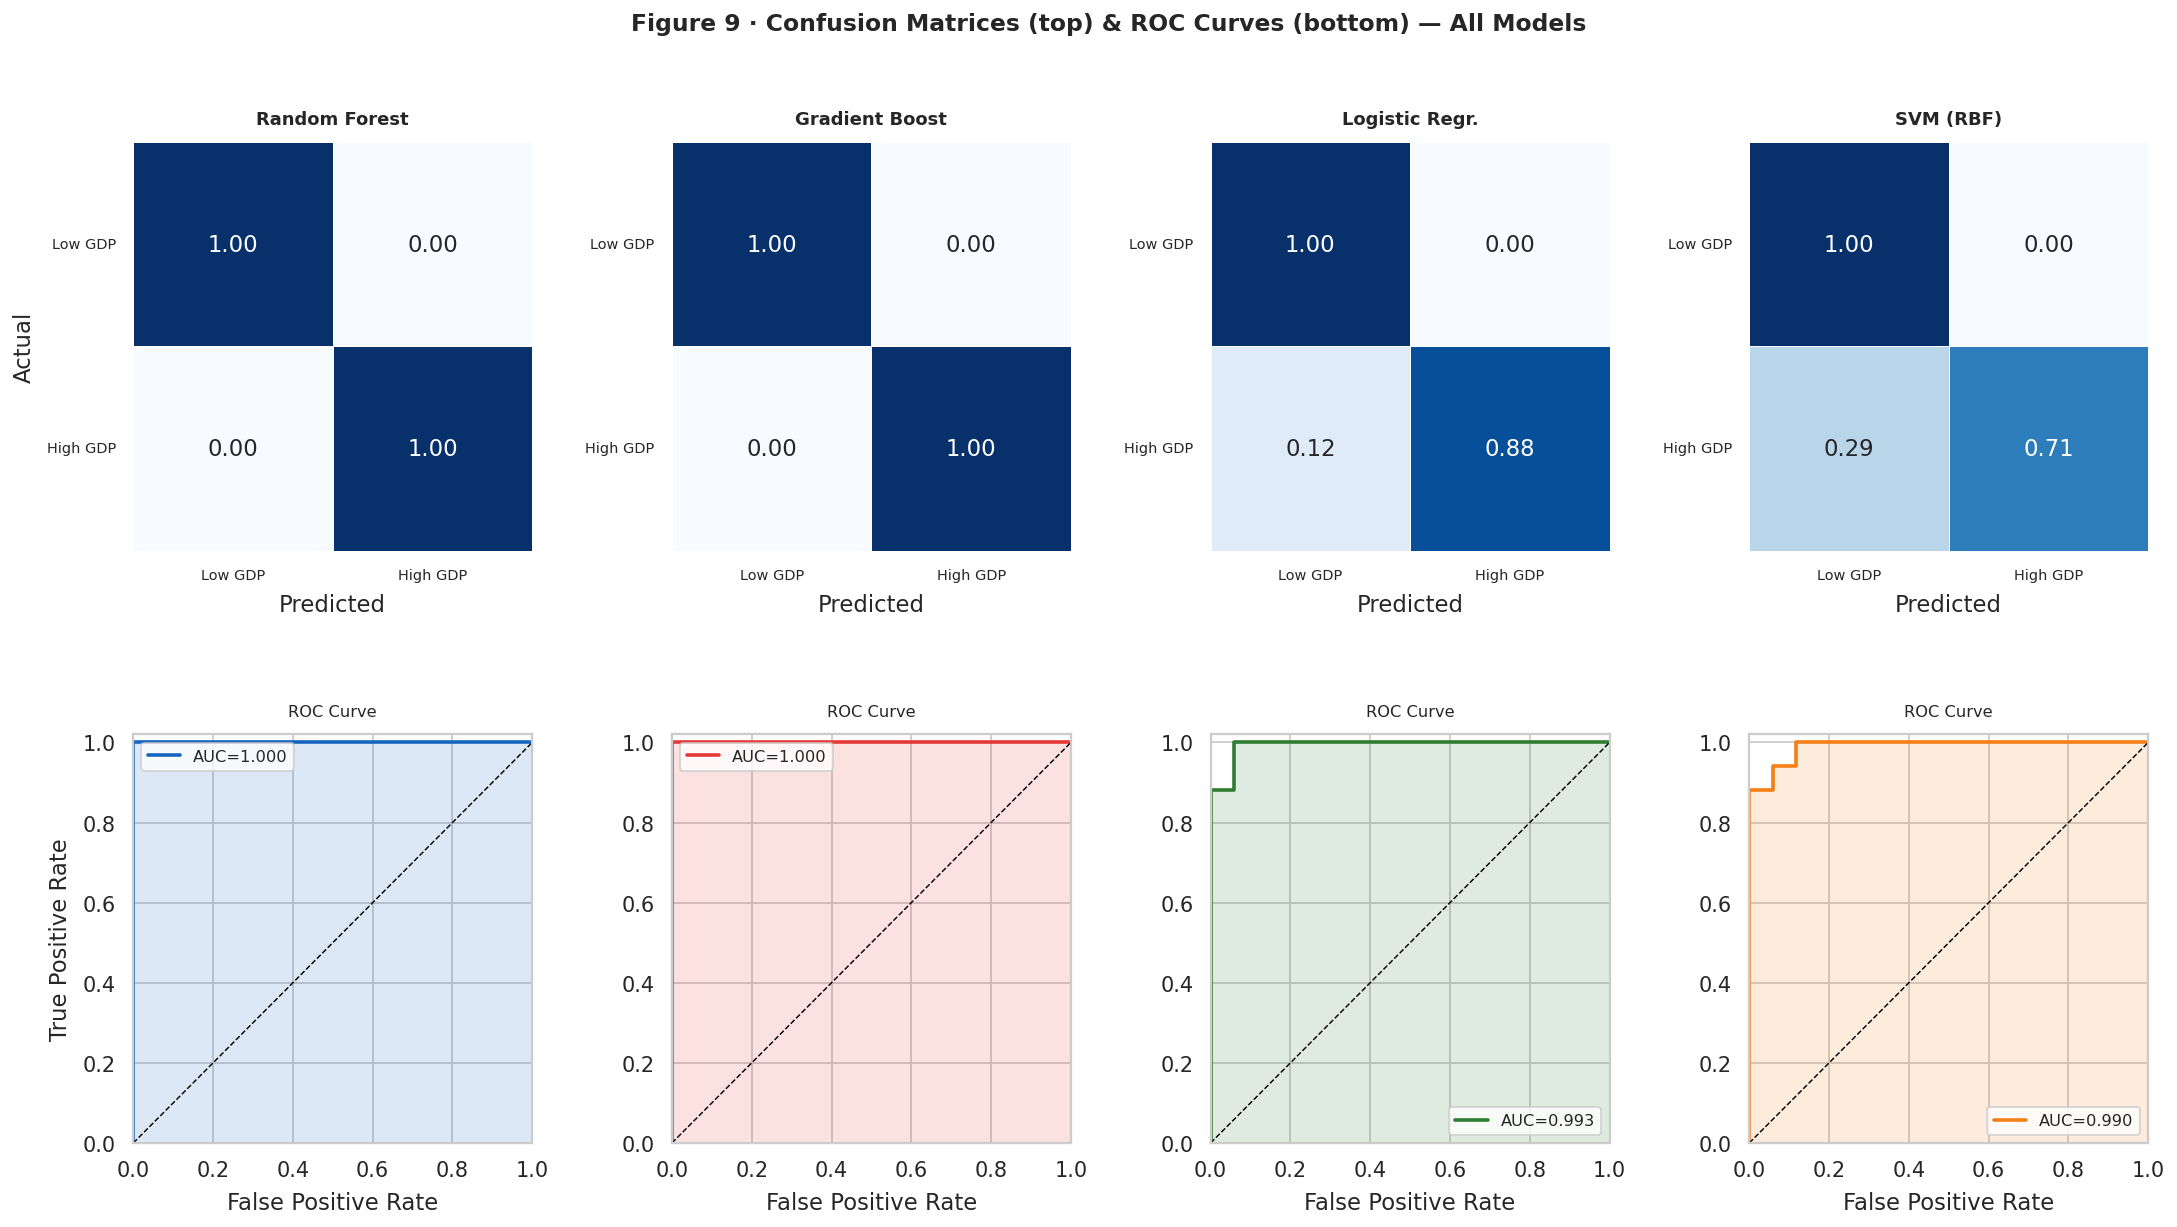

In [ ]:
# ── Confusion matrices + ROC curves ─────────────────────────────────
n_models = len(models)
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, n_models, hspace=0.45, wspace=0.35)

for col_idx, (name, res) in enumerate(results.items()):
    ax_cm  = fig.add_subplot(gs[0, col_idx])
    cm_norm = res["cm"].astype(float) / res["cm"].sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                cmap="Blues", ax=ax_cm, linewidths=0.5,
                cbar=False, vmin=0, vmax=1)
    ax_cm.set_title(name, fontweight="bold", fontsize=10)
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("Actual" if col_idx == 0 else "")
    ax_cm.set_xticklabels(["Low GDP","High GDP"], fontsize=8)
    ax_cm.set_yticklabels(["Low GDP","High GDP"], fontsize=8, rotation=0)

    ax_roc = fig.add_subplot(gs[1, col_idx])
    if res["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
        ax_roc.plot(fpr, tpr, lw=2, color=PALETTE[col_idx],
                    label=f"AUC={res['roc_auc']:.3f}")
        ax_roc.fill_between(fpr, tpr, alpha=0.15, color=PALETTE[col_idx])
    ax_roc.plot([0,1],[0,1],"k--", linewidth=0.8)
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate" if col_idx == 0 else "")
    ax_roc.set_title("ROC Curve", fontsize=9)
    ax_roc.legend(fontsize=9)
    ax_roc.set_xlim([0,1]); ax_roc.set_ylim([0,1.02])

plt.suptitle("Figure 9 · Confusion Matrices (top) & ROC Curves (bottom) \u2014 All Models",
             fontsize=13, fontweight="bold")
plt.savefig(f"{cfg.data_dir}/fig9_cm_roc.png",
            bbox_inches="tight", dpi=150)
plt.show()

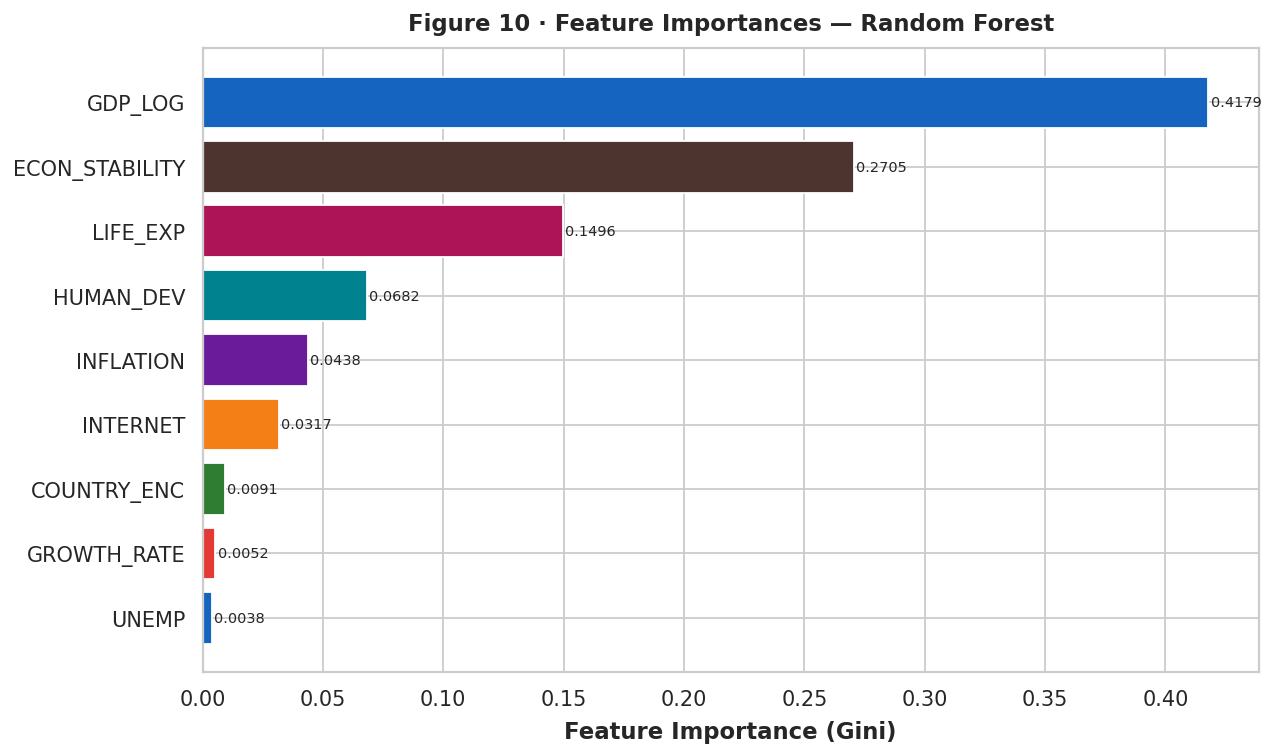


🏆 Best model: Random Forest  (CV F1 = 0.9926)
   Model serialised → pipeline_data/best_model_Random_Forest.pkl


In [ ]:
# ── Feature importance (best model) + model persistence ─────────────
best_model_name = max(results, key=lambda n: results[n]["cv_mean"])
best_clf        = results[best_model_name]["clf"]

if hasattr(best_clf, "feature_importances_"):
    importances = best_clf.feature_importances_
    fi_df = pd.DataFrame({"Feature": clf_features, "Importance": importances})
    fi_df = fi_df.sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(fi_df["Feature"], fi_df["Importance"],
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(fi_df))],
                   edgecolor="white")
    for bar, val in zip(bars, fi_df["Importance"]):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)
    ax.set_xlabel("Feature Importance (Gini)", fontweight="bold")
    ax.set_title(f"Figure 10 · Feature Importances \u2014 {best_model_name}",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{cfg.data_dir}/fig10_feature_importance.png",
                bbox_inches="tight", dpi=150)
    plt.show()

# ── Persist best model ───────────────────────────────────────────────
model_path = f"{cfg.data_dir}/best_model_{best_model_name.replace(' ','_')}.pkl"
joblib.dump(best_clf, model_path)
log.info("Best model saved \u2192 %s", model_path)

print(f"\n\U0001f3c6 Best model: {best_model_name}  "
      f"(CV F1 = {results[best_model_name]['cv_mean']:.4f})")
print(f"   Model serialised \u2192 {model_path}")

---
## Section 9 · Summary Dashboard

A single-cell consolidated view of all major findings from the pipeline.

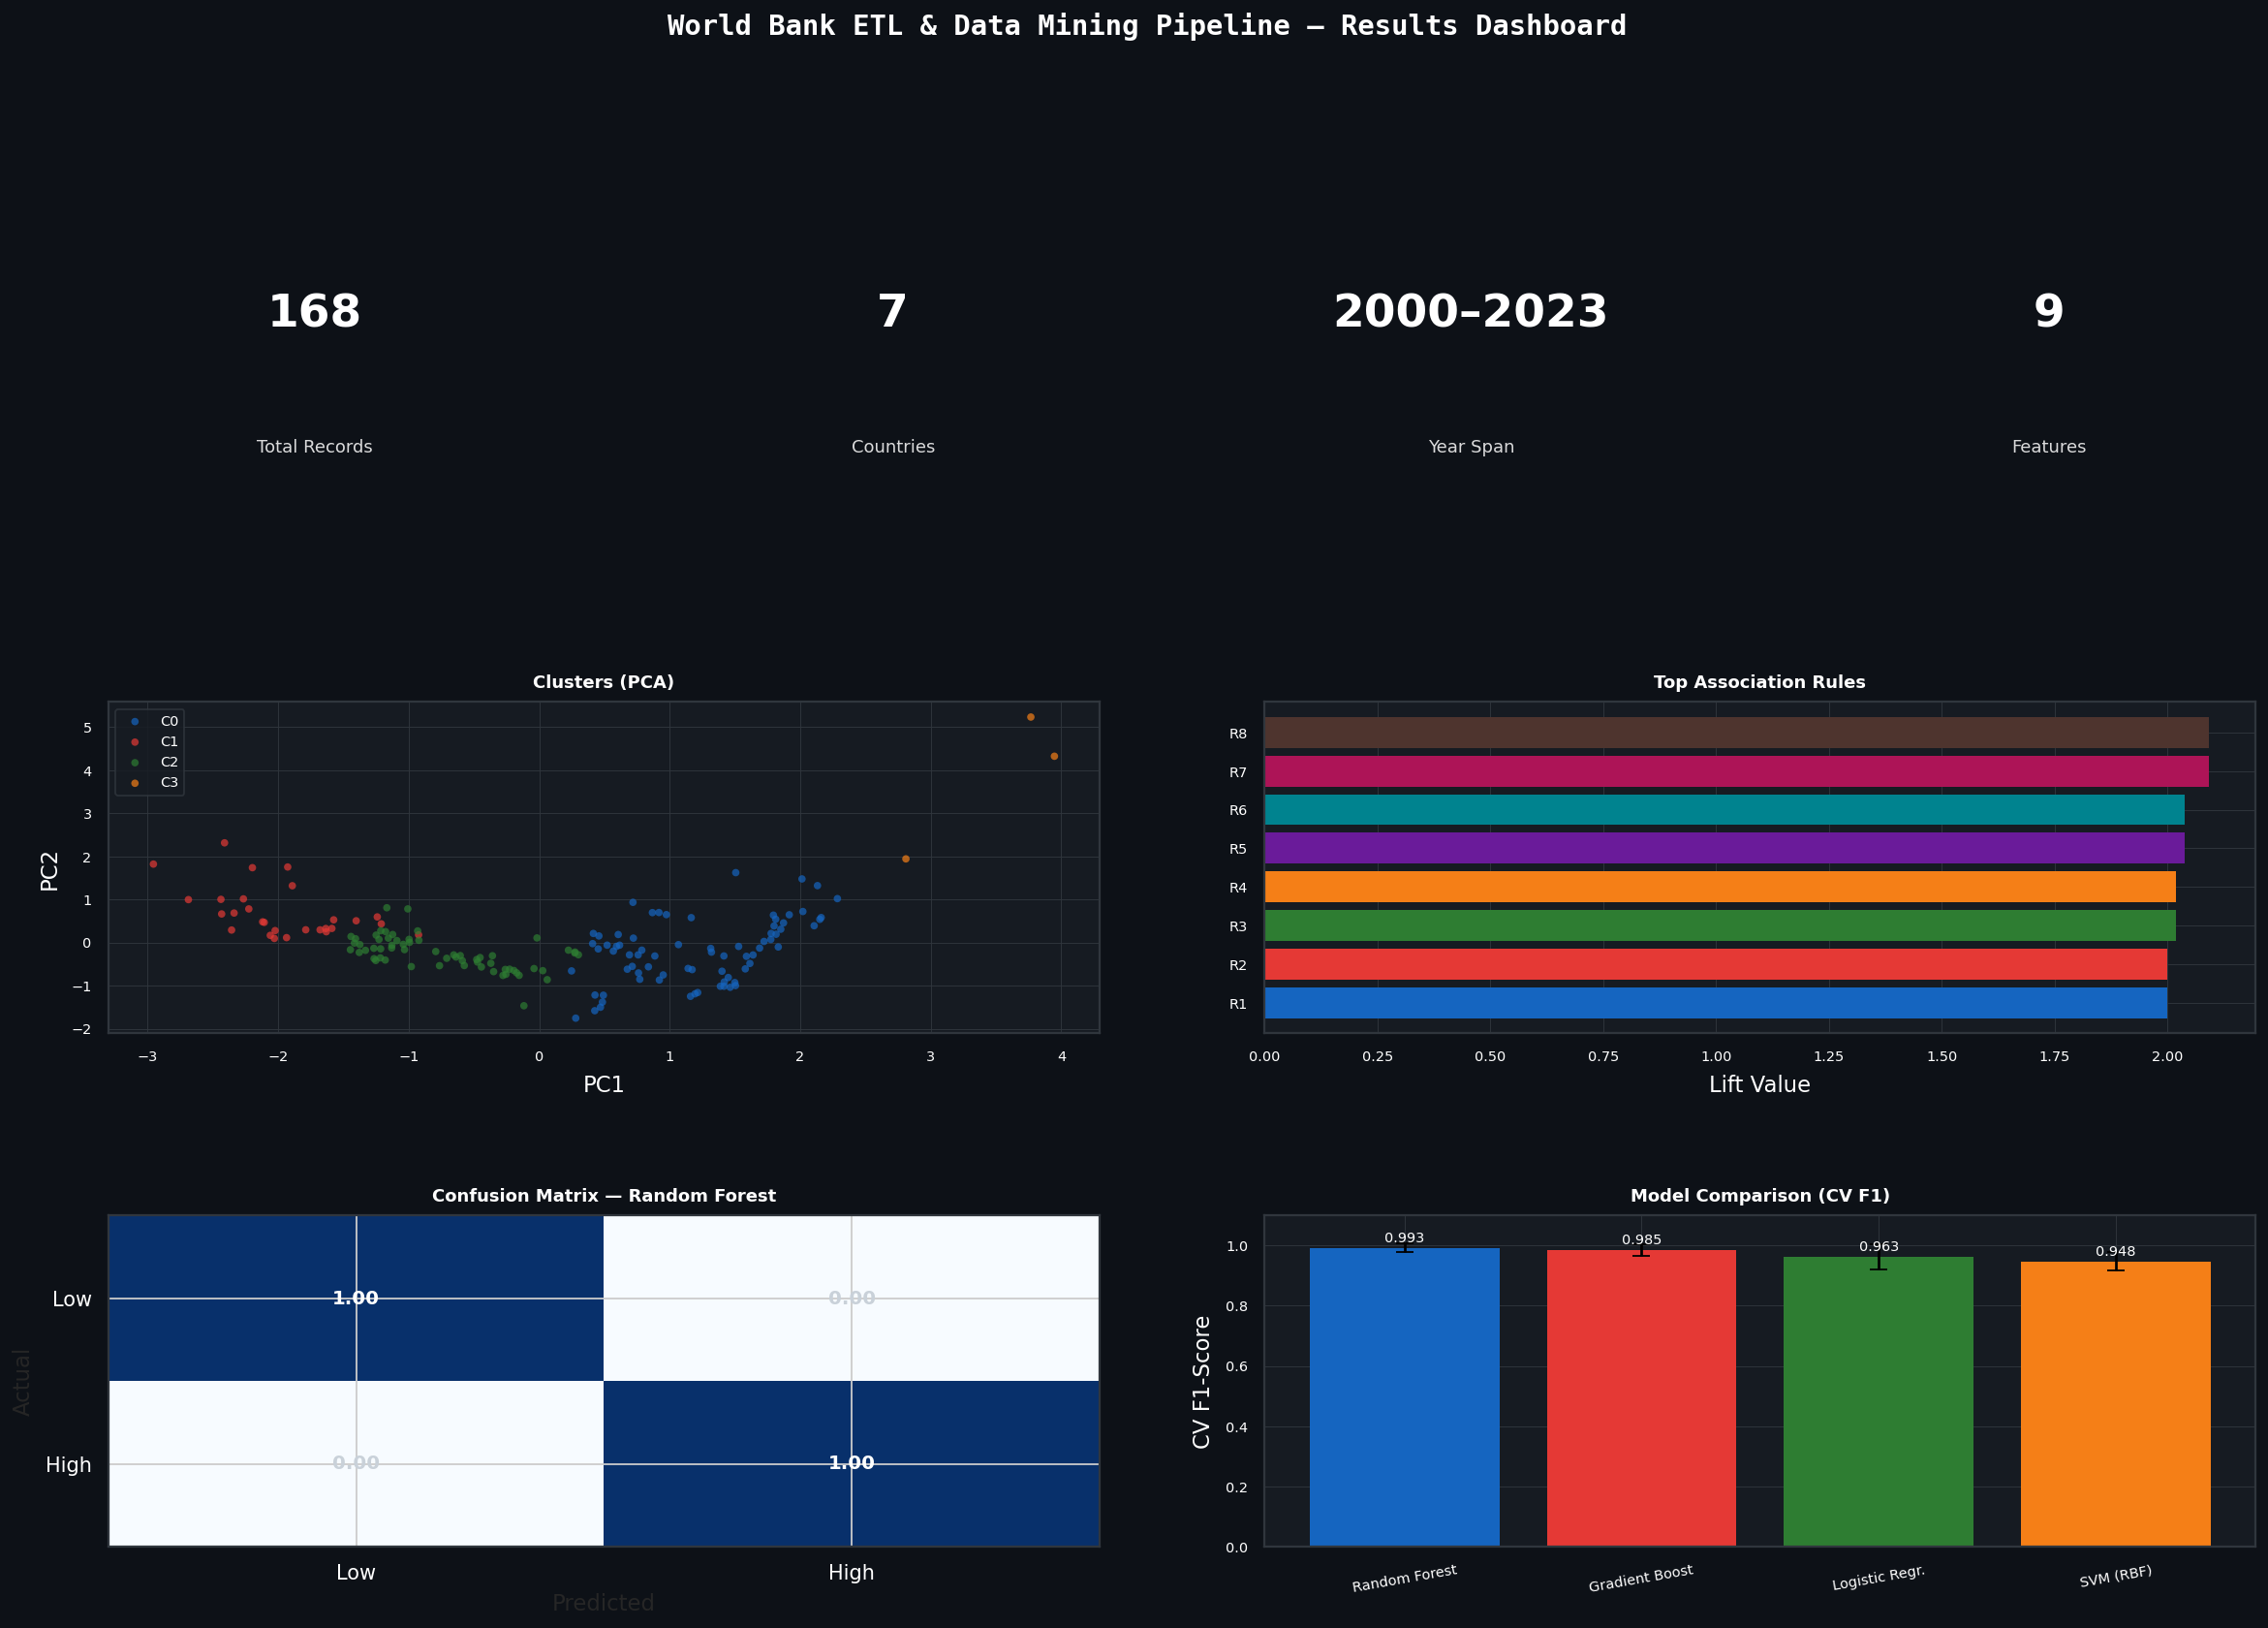


✅  Pipeline complete. All figures saved to pipeline_data


In [ ]:
# ──────────────────────────────────────────────────────────────────
# Section 9 · Summary Dashboard
# ──────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor("#0D1117")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

title_kw = dict(fontweight="bold", color="white", fontsize=10, pad=8)
DARK_AX  = "#161B22"
GRID_COL = "#30363D"

def style_ax(ax):
    ax.set_facecolor(DARK_AX)
    ax.tick_params(colors="white", labelsize=8)
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax.grid(color=GRID_COL, linewidth=0.5)

# ── KPI tiles (row 0, col 0–3) ──────────────────────────────────────
kpis = [
    ("Total Records",  f"{len(df_clean):,}",                          "#1565C0"),
    ("Countries",      str(df_clean['country_code'].nunique()),        "#2E7D32"),
    ("Year Span",      f"{df_clean['year'].min()}\u2013{df_clean['year'].max()}", "#AD1457"),
    ("Features",       str(len(clf_features)),                         "#E65100"),
]
for col_i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col_i])
    ax.set_facecolor(color)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis("off")
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=26, fontweight="bold", color="white")
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=10, color="white", alpha=0.85)

# ── PCA cluster scatter (row 1, col 0–1) ────────────────────────────
ax_pca = fig.add_subplot(gs[1, 0:2])
style_ax(ax_pca)
for k in range(cfg.n_clusters):
    mask = df_clust["cluster"] == k
    ax_pca.scatter(df_clust.loc[mask,"PC1"], df_clust.loc[mask,"PC2"],
                   c=PALETTE[k], s=18, alpha=0.7, label=f"C{k}", edgecolors="none")
ax_pca.set_xlabel("PC1"); ax_pca.set_ylabel("PC2")
ax_pca.set_title("Clusters (PCA)", **title_kw)
ax_pca.legend(fontsize=8, labelcolor="white", facecolor=DARK_AX, edgecolor=GRID_COL)

# ── Top rules by lift (row 1, col 2–3) ──────────────────────────────
ax_rules = fig.add_subplot(gs[1, 2:4])
style_ax(ax_rules)
n_bar = min(8, len(rules))
bar_rules  = rules.head(n_bar).copy()
bar_labels = [f"R{i+1}" for i in range(n_bar)]
ax_rules.barh(bar_labels, bar_rules["lift"].values[::-1],
              color=PALETTE[:n_bar], edgecolor="none")
ax_rules.set_xlabel("Lift Value")
ax_rules.set_title("Top Association Rules", **title_kw)

# ── Best model confusion matrix (row 2, col 0–1) ─────────────────────
ax_cm  = fig.add_subplot(gs[2, 0:2])
cm_data = results[best_model_name]["cm"].astype(float)
cm_data /= cm_data.sum(axis=1, keepdims=True)
im = ax_cm.imshow(cm_data, cmap="Blues", aspect="auto", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f"{cm_data[i,j]:.2f}",
                   ha="center", va="center",
                   color="white" if cm_data[i,j] > 0.5 else "#c9d1d9",
                   fontsize=11, fontweight="bold")
ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
ax_cm.set_xticklabels(["Low","High"], color="white")
ax_cm.set_yticklabels(["Low","High"], color="white")
ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")
ax_cm.set_title(f"Confusion Matrix \u2014 {best_model_name}", **title_kw)
for spine in ax_cm.spines.values(): spine.set_edgecolor(GRID_COL)

# ── CV scores bar (row 2, col 2–3) ───────────────────────────────────
ax_cv = fig.add_subplot(gs[2, 2:4])
style_ax(ax_cv)
model_names = list(results.keys())
cv_means    = [results[n]["cv_mean"] for n in model_names]
cv_stds     = [results[n]["cv_std"]  for n in model_names]
bars = ax_cv.bar(model_names, cv_means, yerr=cv_stds,
                  color=PALETTE[:len(model_names)],
                  capsize=5, edgecolor="none")
ax_cv.set_ylim(0, 1.1)
ax_cv.set_ylabel("CV F1-Score")
ax_cv.set_title("Model Comparison (CV F1)", **title_kw)
ax_cv.tick_params(axis="x", labelrotation=10)
for bar, val in zip(bars, cv_means):
    ax_cv.text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 0.02, f"{val:.3f}",
               ha="center", fontsize=8, color="white")

fig.text(0.5, 0.98,
         "World Bank ETL & Data Mining Pipeline \u2014 Results Dashboard",
         ha="center", va="top", fontsize=16, fontweight="bold",
         color="white", fontfamily="monospace")

plt.savefig(f"{cfg.data_dir}/fig11_dashboard.png",
            bbox_inches="tight", dpi=150, facecolor="#0D1117")
plt.show()
print("\n\u2705  Pipeline complete. All figures saved to", cfg.data_dir)

### Download Pipeline Outputs
Compresses the `pipeline_data/` directory into a single ZIP and downloads it.

In [ ]:
import zipfile, os

zip_filename = "worldbank_pipeline_results.zip"
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(cfg.data_dir):
        for file in files:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath))
print(f"\u2705  Archive created: {zip_filename}")

# Download in Colab; print path otherwise (works in any environment)
try:
    from google.colab import files
    files.download(zip_filename)
except ImportError:
    print(f"   Not running in Colab \u2014 file saved at: {os.path.abspath(zip_filename)}")

✅  Archive created: worldbank_pipeline_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>